# 1) Dataset Info

This section gives a basic overview of the dataset. The goal is to understand the structure, types of data, and any potential issues before diving deeper into analysis.

### Steps:
- Import necessary libraries
- Perform a basic inspection of the dataset:
  - View dataset shape (rows, columns)
  - Check data types (`dtypes`) of each column
  - Use `.info()` to see non-null counts and types
  - Use `.describe()` for summary statistics of numeric columns
  - List all column names
- Check for missing/null values
- Write a variable description for each column to explain what kind of data it holds
- Add a short conclusion/comment after each inspection step explaining what it reveals about the data


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
#Load the dataset 
df = pd.read_csv("FIFA24_PlayerStats.csv")

#Dataset contains 41 columns and they can't be loaded all together so we use this method to load them all together
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [3]:
#Check the first 5 rows to get the basic idea about dataset:
df.head()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,att_position,interceptions,vision,composure,crossing,short_pass,long_pass,acceleration,stamina,strength,balance,sprint_speed,agility,jumping,heading,shot_power,finishing,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
0,Cristian Castro Devenish,Colombia,192,84,22,Atl. Nacional,55,43,NaN,68,73,72,68,30,65,30,50,33,64,49,41,55,86,40,52,43,51,64,54,30,31,32,34,41,33,10,11,6,7,9,$1.400.000
1,Silaldo Taffarel,Brazil,181,80,31,Corinthians,69,70,NaN,56,58,62,70,69,70,64,54,60,63,63,64,87,81,42,67,65,65,54,60,64,68,65,62,48,46,12,15,14,8,14,$975.00
2,Thomas Dähne,Germany,193,84,29,Holstein Kiel,25,12,NaN,13,16,27,65,17,20,49,48,14,35,18,46,38,68,41,48,36,60,17,51,14,20,20,15,26,16,64,74,65,68,74,$1.100.000
3,Michael Sollbauer,Austria,187,86,33,SK Rapid Wien,46,48,NaN,66,69,71,64,48,66,29,70,44,58,53,35,73,82,56,63,57,80,67,32,24,33,25,13,22,19,10,10,8,14,9,$650.00
4,Diego Segovia,Uruguay,191,80,23,Independiente,14,8,NaN,14,16,28,50,10,12,38,34,11,23,20,38,28,64,24,31,34,27,13,48,4,6,9,10,16,5,61,59,62,64,64,$300.00


In [4]:
df.columns

Index(['player', 'country', 'height', 'weight', 'age', 'club', 'ball_control', 'dribbling', 'marking', 'slide_tackle', 'stand_tackle', 'aggression', 'reactions', 'att_position', 'interceptions', 'vision', 'composure', 'crossing', 'short_pass', 'long_pass', 'acceleration', 'stamina', 'strength', 'balance', 'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys', 'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'value'], dtype='object')

In [5]:
print(f'the dataset has {df.shape[0]} rows and {df.shape[1]} columns')

the dataset has 5680 rows and 41 columns


## Variable Descriptions

### Basic Info
- **player** — Name of the player.
- **country** — Nationality of the player.
- **height** — Player’s height in centimeters (cm).
- **weight** — Player’s weight in kilograms (kg).
- **age** — Player’s age in years.
- **club** — Club the player currently plays for.
- **value** — Market value of the player (e.g., $1.400.000 = 1.4 million USD).

---

### Technical & Offensive Attributes
- **ball_control** — Player’s ability to control the ball during possession.
- **dribbling** — Skill in maneuvering the ball while evading defenders.
- **crossing** — Accuracy and quality of crosses from wide areas.
- **short_pass** — Effectiveness in short-range passing.
- **long_pass** — Ability to deliver accurate long-range passes.
- **curve** — How much curve/spin the player can apply to the ball.
- **finishing** — Capability to convert shots into goals from close range.
- **volleys** — Skill in striking the ball while it’s in the air (before it touches the ground).
- **long_shots** — Proficiency in shooting accurately from long distances.
- **fk_acc** — Accuracy in taking direct free kicks.
- **penalties** — Effectiveness in taking penalty kicks.
- **shot_power** — Power behind the player’s shots.
- **att_position** — Ability to position themselves well in attacking situations.

---

### Defensive Attributes
- **marking** — Skill in closely marking and tracking opponents (contains NaNs).
- **slide_tackle** — Effectiveness in executing slide tackles.
- **stand_tackle** — Competence in standing tackles to dispossess players.
- **interceptions** — Ability to read the game and intercept passes.

---

### Physical & Athletic Attributes
- **acceleration** — How quickly a player reaches top speed.
- **sprint_speed** — Top running speed of the player.
- **agility** — Quickness and ease of movement/change of direction.
- **stamina** — Ability to maintain performance throughout the match.
- **strength** — Physical power and ability to hold off opponents.
- **balance** — Stability and control while in motion or under pressure.
- **jumping** — Vertical leap height.
- **heading** — Accuracy and power in heading the ball.

---

### Mental Attributes
- **reactions** — Speed at which the player responds to in-game events.
- **vision** — Ability to spot and execute key passes.
- **composure** — Performance under pressure and ability to stay calm.
- **aggression** — Level of assertiveness and physical engagement.

---

### Goalkeeper-Specific Attributes
*(These are mostly relevant for goalkeepers; will be low or zero for outfield players)*
- **gk_positioning** — Ability to position correctly in goal during shots.
- **gk_diving** — Diving skill to save shots.
- **gk_handling** — Ability to catch or hold on to the ball.
- **gk_kicking** — Accuracy and power in goal kicks or distribution.
- **gk_reflexes** — Quick reaction to make close-range or sudden saves.

In [6]:
#Basic Stats of the dataset
df.describe()

,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,att_position,interceptions,vision,composure,crossing,short_pass,long_pass,acceleration,stamina,strength,balance,sprint_speed,agility,jumping,heading,shot_power,finishing,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes
count,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,0.0,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000
mean,181.671831,75.283803,26.315845,58.901761,56.116373,NaN,46.732570,48.824648,56.319366,61.948768,50.710739,47.392958,54.455458,58.611268,49.780458,59.324472,53.904754,64.744366,63.369366,65.378169,64.063204,64.949648,63.770246,65.079049,52.236268,58.173063,46.339261,47.152641,48.089085,43.291373,48.163908,42.919190,16.190141,16.439789,16.194894,16.073768,16.572535
std,6.829680,6.999642,4.730292,16.560609,18.764235,NaN,20.521785,20.978541,16.847245,8.876965,19.769662,20.453887,13.696858,12.015176,17.893373,14.320748,14.600409,15.291341,16.103125,12.625184,14.492776,15.108142,14.850367,12.272221,17.355420,12.963987,19.809825,19.457000,18.080833,17.083868,15.773335,17.902821,17.149019,17.638100,16.995298,16.811196,17.944732
min,156.000000,54.000000,17.000000,8.000000,5.000000,NaN,7.000000,7.000000,11.000000,32.000000,3.000000,3.000000,10.000000,13.000000,6.000000,11.000000,9.000000,12.000000,14.000000,25.000000,20.000000,13.000000,21.000000,23.000000,6.000000,20.000000,4.000000,5.000000,7.000000,4.000000,8.000000,4.000000,2.000000,2.000000,2.000000,2.000000,3.000000
25%,177.000000,70.000000,23.000000,55.000000,51.000000,NaN,27.000000,30.000000,45.000000,56.000000,40.000000,28.000000,45.000000,52.000000,39.000000,55.000000,46.000000,57.000000,56.000000,58.000000,56.000000,57.000000,56.000000,57.000000,45.000000,49.000000,31.000000,33.000000,36.000000,32.000000,39.000000,30.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,182.000000,75.000000,26.000000,63.000000,62.000000,NaN,54.000000,57.000000,60.000000,62.000000,56.000000,54.000000,56.000000,60.000000,54.000000,63.000000,57.000000,68.000000,66.000000,66.000000,66.000000,68.000000,66.000000,66.000000,55.000000,59.000000,50.500000,51.000000,50.000000,43.000000,49.000000,44.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,186.000000,80.000000,30.000000,69.000000,68.000000,NaN,64.000000,66.000000,69.000000,68.000000,65.000000,64.000000,65.000000,67.000000,63.000000,68.000000,64.000000,75.000000,74.000000,74.000000,74.000000,75.000000,74.000000,73.000000,64.000000,68.000000,62.000000,62.000000,62.000000,56.000000,60.000000,57.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,204.000000,102.000000,41.000000,94.000000,95.000000,NaN,87.000000,91.000000,96.000000,93.000000,93.000000,89.000000,94.000000,96.000000,94.000000,93.000000,93.000000,97.000000,95.000000,96.000000,95.000000,97.000000,93.000000,95.000000,93.000000,94.000000,94.000000,91.000000,93.000000,94.000000,92.000000,90.000000,90.000000,90.000000,87.000000,90.000000,89.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 41 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   player          5680 non-null   object 
 1   country         5680 non-null   object 
 2   height          5680 non-null   int64  
 3   weight          5680 non-null   int64  
 4   age             5680 non-null   int64  
 5   club            5680 non-null   object 
 6   ball_control    5680 non-null   int64  
 7   dribbling       5680 non-null   int64  
 8   marking         0 non-null      float64
 9   slide_tackle    5680 non-null   int64  
 10  stand_tackle    5680 non-null   int64  
 11  aggression      5680 non-null   int64  
 12  reactions       5680 non-null   int64  
 13  att_position    5680 non-null   int64  
 14  interceptions   5680 non-null   int64  
 15  vision          5680 non-null   int64  
 16  composure       5680 non-null   int64  
 17  crossing        5680 non-null   i

In [8]:
#Check for datatypes  
df.dtypes

player             object
country            object
height              int64
weight              int64
age                 int64
club               object
ball_control        int64
dribbling           int64
marking           float64
slide_tackle        int64
stand_tackle        int64
aggression          int64
reactions           int64
att_position        int64
interceptions       int64
vision              int64
composure           int64
crossing            int64
short_pass          int64
long_pass           int64
acceleration        int64
stamina             int64
strength            int64
balance             int64
sprint_speed        int64
agility             int64
jumping             int64
heading             int64
shot_power          int64
finishing           int64
long_shots          int64
curve               int64
fk_acc              int64
penalties           int64
volleys             int64
gk_positioning      int64
gk_diving           int64
gk_handling         int64
gk_kicking  

In [9]:
#Check for Null Values + The percentage of Null Values 
df.isnull().sum()

player               0
country              0
height               0
weight               0
age                  0
club                 0
ball_control         0
dribbling            0
marking           5680
slide_tackle         0
stand_tackle         0
aggression           0
reactions            0
att_position         0
interceptions        0
vision               0
composure            0
crossing             0
short_pass           0
long_pass            0
acceleration         0
stamina              0
strength             0
balance              0
sprint_speed         0
agility              0
jumping              0
heading              0
shot_power           0
finishing            0
long_shots           0
curve                0
fk_acc               0
penalties            0
volleys              0
gk_positioning       0
gk_diving            0
gk_handling          0
gk_kicking           0
gk_reflexes          0
value                0
dtype: int64

we'll have to just drop or engineer the **marking** column other columns are free of null values

In [10]:
print("% of Null values in marking column")
(df['marking'].isnull().mean()*100)

% of Null values in marking column


100.0

### Get the numerical and categorical columns 


In [11]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Categorical Columns {categorical_cols}\n\nNumerical columns {numerical_cols}')

Categorical Columns ['player', 'country', 'club', 'value']

Numerical columns ['height', 'weight', 'age', 'ball_control', 'dribbling', 'marking', 'slide_tackle', 'stand_tackle', 'aggression', 'reactions', 'att_position', 'interceptions', 'vision', 'composure', 'crossing', 'short_pass', 'long_pass', 'acceleration', 'stamina', 'strength', 'balance', 'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys', 'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes']


these cols will be later used for univariate analysis

# Univariate Analysis

In this section, we analyze each feature individually to understand its distribution, frequency, and overall behavior. Univariate analysis is a crucial step in EDA, as it helps us identify trends, outliers, and potential data quality issues.

We categorize features into two types for this analysis:

### 1. Categorical Features
- These are non-numeric columns such as player name, country, or club.
- We analyze them using visualizations like `countplot` or `barplot` to see how frequently each category appears.

### 2. Numerical Features
- These are continuous or discrete numeric values such as age, height, weight, or skill ratings.
- We use plots like `histplot`, `boxplot`, and basic statistical summaries to understand their distribution, range, and any potential outliers.

This step helps build a deeper understanding of each variable before we explore relationships between them in bivariate analysis.ate analysis.


### Categorical Univariate:
- we'll only plot top 20's for each categorical column because it'll be less insightful if we draw all 5000 rows

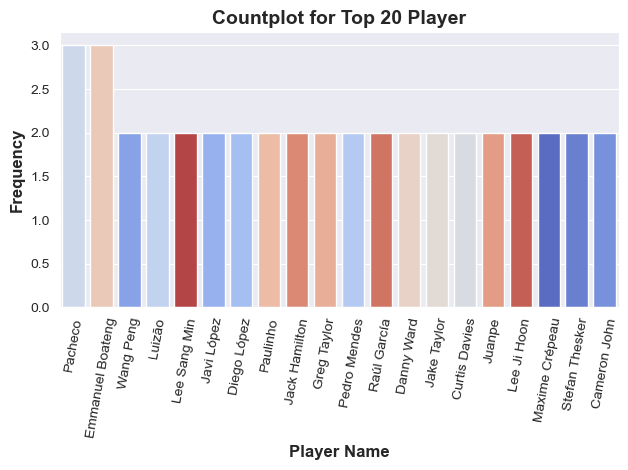

In [12]:
#Countplot for top20 players 
sns.set_style("darkgrid")
top_20 = df['player'].value_counts().nlargest(20).index
filtered_df = df[df['player'].isin(top_20)]
sns.countplot(data=filtered_df, x='player', order=top_20,legend=False,hue='player',palette='coolwarm')
plt.xlabel('Player Name',fontweight='bold',fontsize=12)
plt.title('Countplot for Top 20 Player',fontweight='bold',fontsize=14)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

**Emmanuel Boateng** and **Pacheco** appear multiple times in the dataset, suggesting either duplicate entries or multiple records due to club transfers or position variations. The rest of the player names show a consistent, non-repetitive distribution, indicating unique entries.

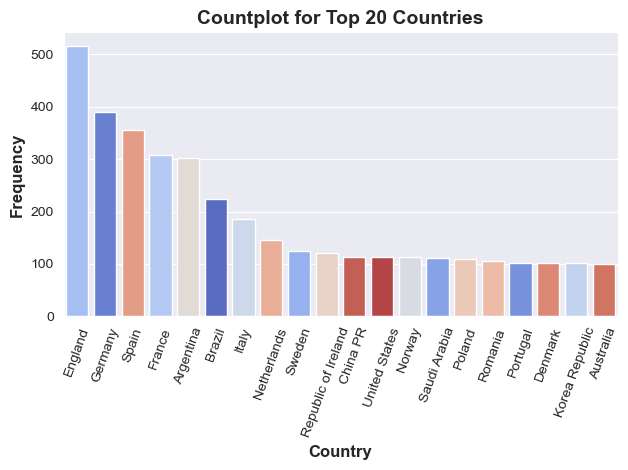

In [13]:
#Countplot for top20 Countries 
sns.set_style("darkgrid")
top_20 = df['country'].value_counts().nlargest(20).index
filtered_df = df[df['country'].isin(top_20)]
sns.countplot(data=filtered_df, x='country', order=top_20,legend=False,hue='country',palette='coolwarm')
plt.xlabel('Country',fontweight='bold',fontsize=12)
plt.title('Countplot for Top 20 Countries',fontweight='bold',fontsize=14)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

**England** tops the chart as the country with the highest number of players in the dataset, indicating a strong representation of English talent in FIFA24. It is followed closely by **Germany** and **Spain**, both of which also contribute significantly to the global player pool.

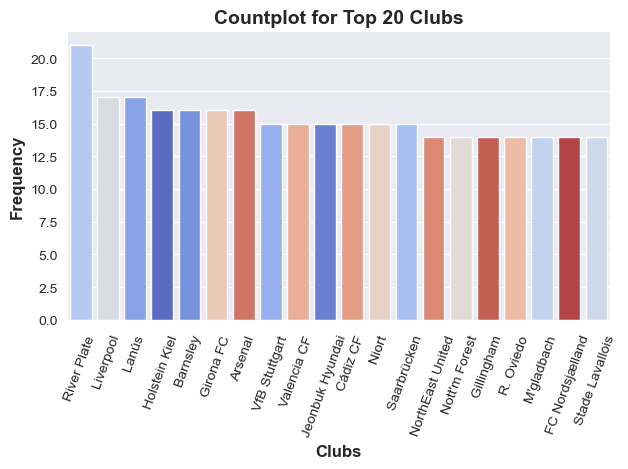

In [14]:
#Countplot for top20 Clubs 
sns.set_style("darkgrid")
top_20 = df['club'].value_counts().nlargest(20).index
filtered_df = df[df['club'].isin(top_20)]
sns.countplot(data=filtered_df, x='club', order=top_20,legend=False,hue='club',palette='coolwarm')
plt.xlabel('Clubs',fontweight='bold',fontsize=12)
plt.title('Countplot for Top 20 Clubs',fontweight='bold',fontsize=14)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

River plate tops the chart followed by Liverpool and Lanus Football Club 

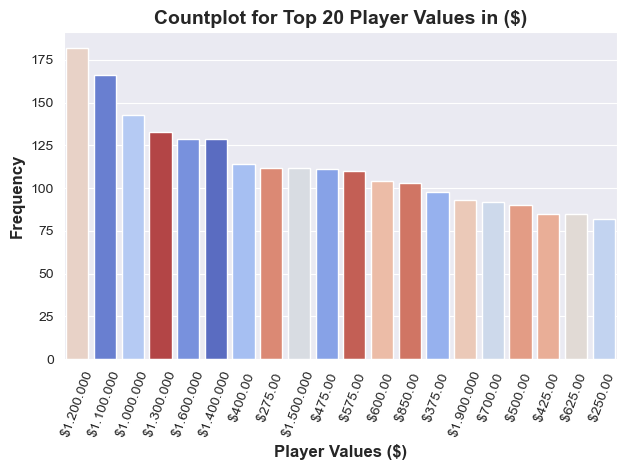

In [15]:
#Countplot for top20 Clubs 
sns.set_style("darkgrid")
top_20 = df['value'].value_counts().nlargest(20).index
filtered_df = df[df['value'].isin(top_20)]
sns.countplot(data=filtered_df, x='value', order=top_20,legend=False,hue='value',palette='coolwarm')
plt.xlabel('Player Values ($)',fontweight='bold',fontsize=12)
plt.title('Countplot for Top 20 Player Values in ($)',fontweight='bold',fontsize=14)
plt.ylabel('Frequency',fontweight='bold',fontsize=12)
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

highest paid athlete is **$1.200.000**

## Numerical Univariate Analysis

In this stage, we explored the distribution of numerical features in the dataset. Rather than visualizing all numerical columns, we selectively analyzed 6–7 key attributes to keep the analysis focused, meaningful, and easy to interpret.

The selected features were chosen based on their relevance to player performance, physical attributes, and market value. These include:

- Age
- Height
- Ball Control
- Sprint Speed
- Strength
- Goalkeeper Reflexes

Histograms were used to visualize the distribution of each selected feature. Key takeaways and observations were noted to better understand player demographics and characteristics. The remaining numerical features were scanned during initial exploration but omitted from visual plots to maintain readability and avoid unnecessary repetition.


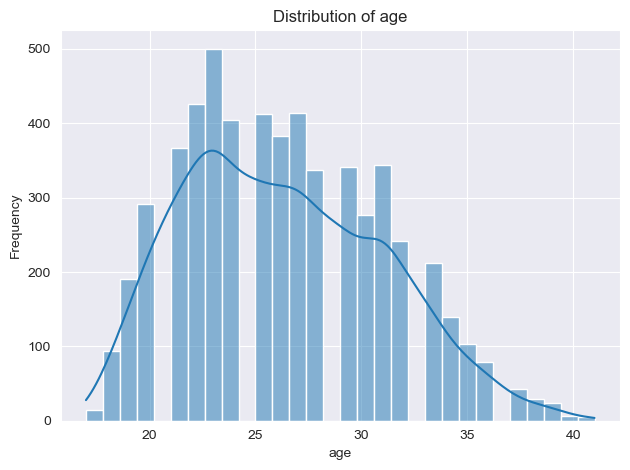

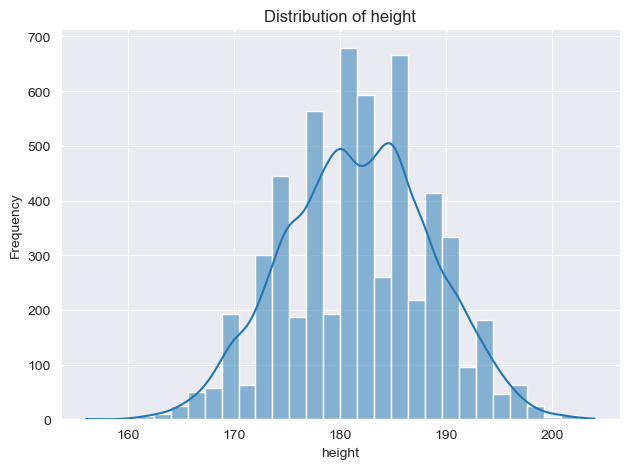

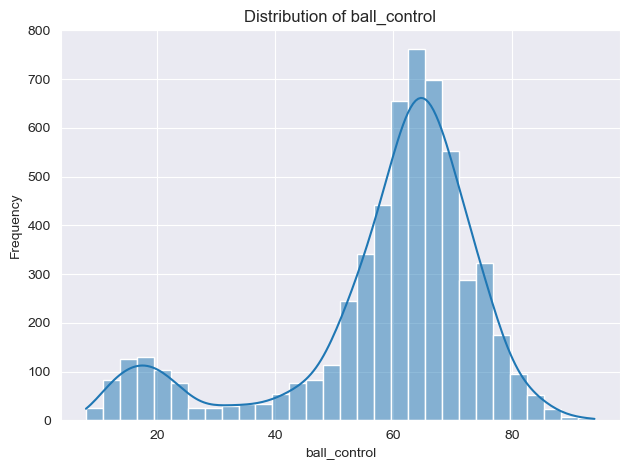

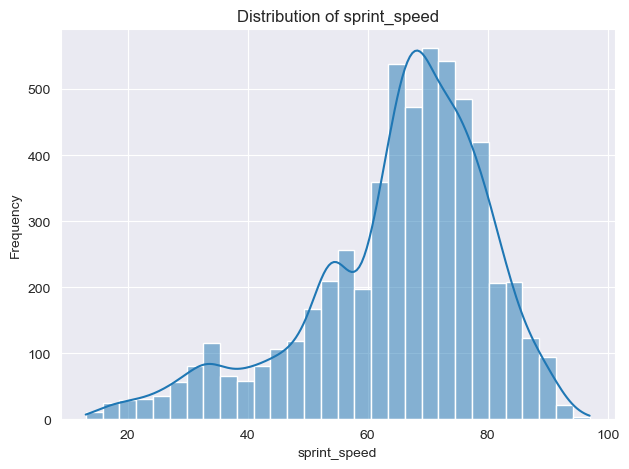

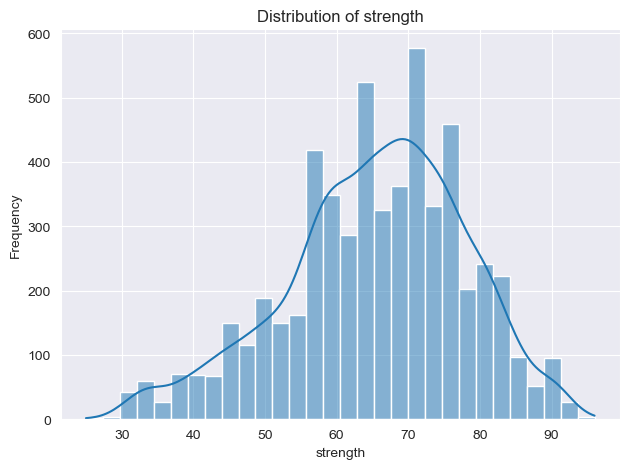

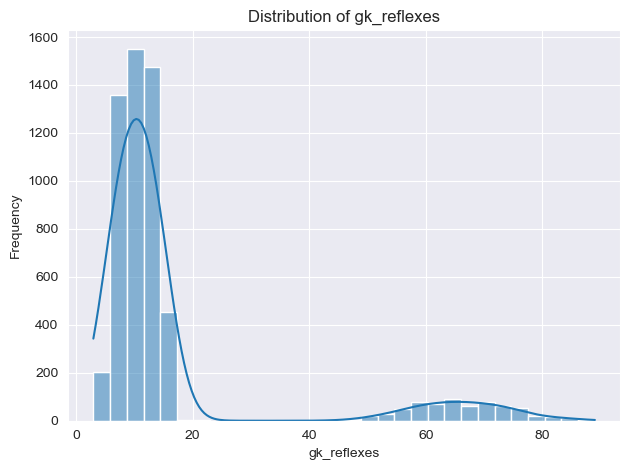

In [16]:
def plot_numerical(feature):
    sns.set_style("darkgrid")
    sns.histplot(df[feature], kde=True, bins=30)
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

features_to_plot = ['age', 'height', 'ball_control', 'sprint_speed', 'strength', 'gk_reflexes']

for col in features_to_plot:
    plot_numerical(col)

> **Note:**  
> This is the Univariate Analysis stage where we are exploring the raw dataset. The focus here is to understand the distribution, frequency, and behavior of individual features.  
> 
> Data cleaning steps such as handling missing values, correcting inconsistencies (e.g., encoding issues), and feature transformation will be performed in the next phase.  
> 
> The purpose of this stage is purely to "get to know the data" before any modifications are made.


# Handling Outliers

In this stage, we'll check for the presence of outliers in key numerical columns.

- If outliers are found, we will handle them accordingly.
- If no significant outliers are detected, we will move on to the next stage.

**Technique Used:**  
We will use the **IQR (Interquartile Range)** method to detect and handle outliers.

To avoid overwhelming visuals, we applied the IQR method across all numerical columns programmatically.

We then selected a few columns for visualization based on the number of detected outliers and relevance.

This ensures clean analysis while maintaining code readability.

In [17]:
df.describe()

,height,weight,age,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,att_position,interceptions,vision,composure,crossing,short_pass,long_pass,acceleration,stamina,strength,balance,sprint_speed,agility,jumping,heading,shot_power,finishing,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes
count,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,0.0,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000,5680.000000
mean,181.671831,75.283803,26.315845,58.901761,56.116373,NaN,46.732570,48.824648,56.319366,61.948768,50.710739,47.392958,54.455458,58.611268,49.780458,59.324472,53.904754,64.744366,63.369366,65.378169,64.063204,64.949648,63.770246,65.079049,52.236268,58.173063,46.339261,47.152641,48.089085,43.291373,48.163908,42.919190,16.190141,16.439789,16.194894,16.073768,16.572535
std,6.829680,6.999642,4.730292,16.560609,18.764235,NaN,20.521785,20.978541,16.847245,8.876965,19.769662,20.453887,13.696858,12.015176,17.893373,14.320748,14.600409,15.291341,16.103125,12.625184,14.492776,15.108142,14.850367,12.272221,17.355420,12.963987,19.809825,19.457000,18.080833,17.083868,15.773335,17.902821,17.149019,17.638100,16.995298,16.811196,17.944732
min,156.000000,54.000000,17.000000,8.000000,5.000000,NaN,7.000000,7.000000,11.000000,32.000000,3.000000,3.000000,10.000000,13.000000,6.000000,11.000000,9.000000,12.000000,14.000000,25.000000,20.000000,13.000000,21.000000,23.000000,6.000000,20.000000,4.000000,5.000000,7.000000,4.000000,8.000000,4.000000,2.000000,2.000000,2.000000,2.000000,3.000000
25%,177.000000,70.000000,23.000000,55.000000,51.000000,NaN,27.000000,30.000000,45.000000,56.000000,40.000000,28.000000,45.000000,52.000000,39.000000,55.000000,46.000000,57.000000,56.000000,58.000000,56.000000,57.000000,56.000000,57.000000,45.000000,49.000000,31.000000,33.000000,36.000000,32.000000,39.000000,30.000000,8.000000,8.000000,8.000000,8.000000,8.000000
50%,182.000000,75.000000,26.000000,63.000000,62.000000,NaN,54.000000,57.000000,60.000000,62.000000,56.000000,54.000000,56.000000,60.000000,54.000000,63.000000,57.000000,68.000000,66.000000,66.000000,66.000000,68.000000,66.000000,66.000000,55.000000,59.000000,50.500000,51.000000,50.000000,43.000000,49.000000,44.000000,11.000000,11.000000,11.000000,11.000000,11.000000
75%,186.000000,80.000000,30.000000,69.000000,68.000000,NaN,64.000000,66.000000,69.000000,68.000000,65.000000,64.000000,65.000000,67.000000,63.000000,68.000000,64.000000,75.000000,74.000000,74.000000,74.000000,75.000000,74.000000,73.000000,64.000000,68.000000,62.000000,62.000000,62.000000,56.000000,60.000000,57.000000,14.000000,14.000000,14.000000,14.000000,14.000000
max,204.000000,102.000000,41.000000,94.000000,95.000000,NaN,87.000000,91.000000,96.000000,93.000000,93.000000,89.000000,94.000000,96.000000,94.000000,93.000000,93.000000,97.000000,95.000000,96.000000,95.000000,97.000000,93.000000,95.000000,93.000000,94.000000,94.000000,91.000000,93.000000,94.000000,92.000000,90.000000,90.000000,90.000000,87.000000,90.000000,89.000000


there are potential outliers in the data which we'll clear and find them by using the IQR method

In [18]:
def detect_outliers_iqr(df, cols):
    outlier_info = []

    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[(df[col] < lower) | (df[col] > upper)]

        if not outliers.empty:
            outlier_info.append({
                'column': col,
                'outlier_count': outliers.shape[0],
                'total': df.shape[0],
                'percent_outliers': round((outliers.shape[0] / df.shape[0]) * 100, 2)
            })

    return pd.DataFrame(outlier_info).sort_values(by='percent_outliers', ascending=False)

iqr_outliers_df = detect_outliers_iqr(df, numerical_cols)

outliers found so we will just drop them but before that let's just visualize some columns like 

weight, age, height to make clear the outliers by the given values above does exist

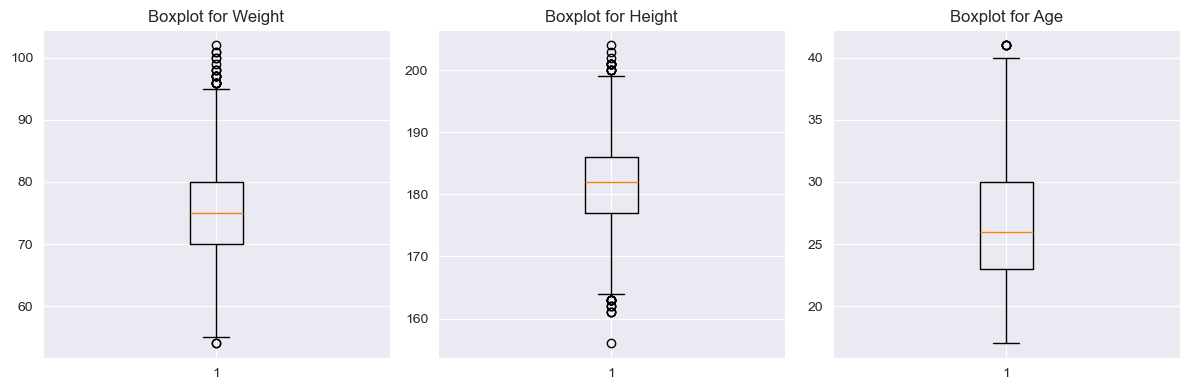

In [19]:
# Final check for outliers using boxplot 
sns.set_style('darkgrid')
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].set_title("Boxplot for Weight")
axes[0].boxplot(df['weight'])

axes[1].set_title("Boxplot for Height")
axes[1].boxplot(df['height'])

axes[2].set_title("Boxplot for Age")
axes[2].boxplot(df['age'])

plt.tight_layout()
plt.show()

**Weight**:  
- We've one lower outlier in weight and few upper outliers too.  

**Height**:  
- We've few lower outliers in height as you can compare it with the table above and few upper outliers too.  

**Age**:  
- We've just one upper outlier in age and no lower outliers.  

The values can be verified by using the table of outliers shown below.


In [20]:
iqr_outliers_df

,column,outlier_count,total,percent_outliers
4,dribbling,657,5680,11.57
25,gk_reflexes,633,5680,11.14
24,gk_kicking,633,5680,11.14
23,gk_handling,633,5680,11.14
22,gk_diving,633,5680,11.14
21,gk_positioning,633,5680,11.14
3,ball_control,628,5680,11.06
8,short_pass,571,5680,10.05
17,heading,529,5680,9.31
11,stamina,316,5680,5.56


In [21]:
#drop the outliers using their indexes
print("Before:", df.shape)
df = df.drop(df.index[[4, 25, 24, 23, 22, 21, 3, 8, 17, 11, 10, 14, 7, 15, 9, 13, 12, 5, 16, 0, 1, 6, 2, 18, 19, 20]])
print("After:", df.shape)

Before: (5680, 41)
After: (5654, 41)


outliers dropped!

# Handling Missing Values and Data Transformation

- Handle missing values using techniques like `fillna()`, `dropna()`, and `replace()`.
- Transform column values such as `club` and `value` for consistency, analysis and other columns if found 

### Marking NaN values Handling 
only marking column has NaN values marking column is basically the defensive ability so we'll use some attributes of player to fill this column instead of dropping it

In [22]:
df['marking'] = df['marking'].fillna(
    df[['slide_tackle', 'stand_tackle', 'interceptions', 'aggression', 'strength']].mean(axis=1)
)

In [23]:
df.isna().sum()
#Missing value Cleaned/filled 

player            0
country           0
height            0
weight            0
age               0
club              0
ball_control      0
dribbling         0
marking           0
slide_tackle      0
stand_tackle      0
aggression        0
reactions         0
att_position      0
interceptions     0
vision            0
composure         0
crossing          0
short_pass        0
long_pass         0
acceleration      0
stamina           0
strength          0
balance           0
sprint_speed      0
agility           0
jumping           0
heading           0
shot_power        0
finishing         0
long_shots        0
curve             0
fk_acc            0
penalties         0
volleys           0
gk_positioning    0
gk_diving         0
gk_handling       0
gk_kicking        0
gk_reflexes       0
value             0
dtype: int64

### Data Transformation
- In this step, we'll identify and fix inconsistent or improperly formatted data. This includes:
 - Handling string values that contain inconsistent formats (e.g., extra spaces, mixed cases, currency symbols).
 - Transforming text-based columns like club and value to ensure uniformity and enable further analysis.

- Example: Converting value from strings like "€1.2M" to numeric float values like 1200000.0.
 - Cleaning club names by removing unwanted characters or fixing capitalization issues.

columns to transform 
`value`

In [ ]:
df['value'] = (
    df['value'].str.replace(r'[\$,]', '', regex=True)  
               .str.replace(r'\.', '', regex=True) 
               .astype(float)
)
df['value'] = (
    df['value'].str.replace('[\\$,]', '', regex=True)
               .str.replace('\\.', '', regex=True)
               .astype(float)
)

In [25]:
# Remove accents and unify spellings 
df['player'] = df['player'].str.normalize('NFKD').str.encode('ascii', errors='ignore').str.decode('utf-8')

In [26]:
df.head()

,player,country,height,weight,age,club,ball_control,dribbling,marking,slide_tackle,stand_tackle,aggression,reactions,att_position,interceptions,vision,composure,crossing,short_pass,long_pass,acceleration,stamina,strength,balance,sprint_speed,agility,jumping,heading,shot_power,finishing,long_shots,curve,fk_acc,penalties,volleys,gk_positioning,gk_diving,gk_handling,gk_kicking,gk_reflexes,value
26,Park Jung Bin,Korea Republic,175,73,29,Rodez AF,59,63,42.2,54,42,41,55,60,26,59,58,59,61,56,74,53,48,76,75,79,51,47,59,57,54,58,60,62,56,8,13,7,13,8,40000.0
27,Kevin Damian Gonzalez,Argentina,169,64,27,Patronato,61,65,32.0,35,32,37,49,49,22,50,53,56,51,45,70,55,34,72,69,68,48,47,60,55,48,45,41,57,64,11,7,6,10,8,22000.0
28,Julian Aude,Argentina,180,65,20,Lanús,74,76,62.6,65,63,64,64,59,62,63,72,62,68,64,74,73,59,76,69,77,59,47,57,41,47,37,38,42,39,6,12,14,7,6,1000000.0
29,Andrew,Brazil,189,76,22,Gil Vicente,14,10,20.8,17,8,24,68,4,8,62,34,9,41,37,47,37,47,32,41,34,44,11,50,4,12,10,8,21,14,68,73,70,66,74,2100000.0
30,Siriki Dembele,Scotland,173,67,26,AJ Auxerre,71,74,39.8,32,38,45,67,68,30,66,65,63,64,54,92,69,54,90,86,86,34,60,69,67,65,54,55,58,67,8,6,10,12,11,1600000.0


`Values` are transformed by removing the $ symbol! and marking is filled by combining two columns and accent for different players removed

# Grouping and Visualizing Columns  
In this notebook, we explore relationships between key columns using groupings and visualizations.  
We'll use plots like bar charts, count plots, and more to uncover insights.  
Grouping helps us spot trends and patterns hidden in raw data.


In [27]:
df.columns

Index(['player', 'country', 'height', 'weight', 'age', 'club', 'ball_control', 'dribbling', 'marking', 'slide_tackle', 'stand_tackle', 'aggression', 'reactions', 'att_position', 'interceptions', 'vision', 'composure', 'crossing', 'short_pass', 'long_pass', 'acceleration', 'stamina', 'strength', 'balance', 'sprint_speed', 'agility', 'jumping', 'heading', 'shot_power', 'finishing', 'long_shots', 'curve', 'fk_acc', 'penalties', 'volleys', 'gk_positioning', 'gk_diving', 'gk_handling', 'gk_kicking', 'gk_reflexes', 'value'], dtype='object')

# Grouping Overview

 ## Skill Groups  
### Technical  
- **Dribblers**: Elite ball carriers with close control and agility  
- **Pass Masters**: Midfield maestros with visionary distribution  

### Defensive  
- **Ball-Winners**: Tenacious tacklers who dominate duels  
- **Silent Destroyers**: Intelligent interceptors with calm under pressure  

### Attacking  
- **Strikers**: Clinical finishers with positional awareness  
- **Long-Shooters**: Specialists in powerful distance strikes  

### Goalkeeping  
- **Elite GKs**: Complete shot-stoppers with strong distribution  
- **Penalty Stoppers**: Reflex specialists with commanding presence  

## Physical Profiles  
- **Dominant CBs**: Aerial powerhouses with physicality  
- **Explosive Wingers**: Pace-driven attackers with endurance  
- **Emerging Talents**: High-potential youngsters with technical foundation  
- **Set-Piece Experts**: Dead-ball specialists with precision  

## Hidden Gems  
- **Complete Players**: Well-rounded bargains with no weaknesses  75 all key stats + value <€20M75 all key stats + value <€20M

## Skill Groups

### Dribbler

In [28]:
#Dribblers
top_dribblers = (
    df[df['dribbling'] >= 90]  
    .sort_values(['dribbling', 'balance', 'agility'], ascending=False)
    .head(10)
    [['player', 'club', 'dribbling', 'balance', 'agility']]
)
top_dribblers

,player,club,dribbling,balance,agility
3555,Lionel Messi,Paris SG,95,95,91
5677,Neymar Jr,Paris SG,95,82,93
5229,Kylian Mbappe,Paris SG,93,81,93
3120,Marco Verratti,Paris SG,91,93,90
3628,Angel Di Maria,Juventus,90,75,91


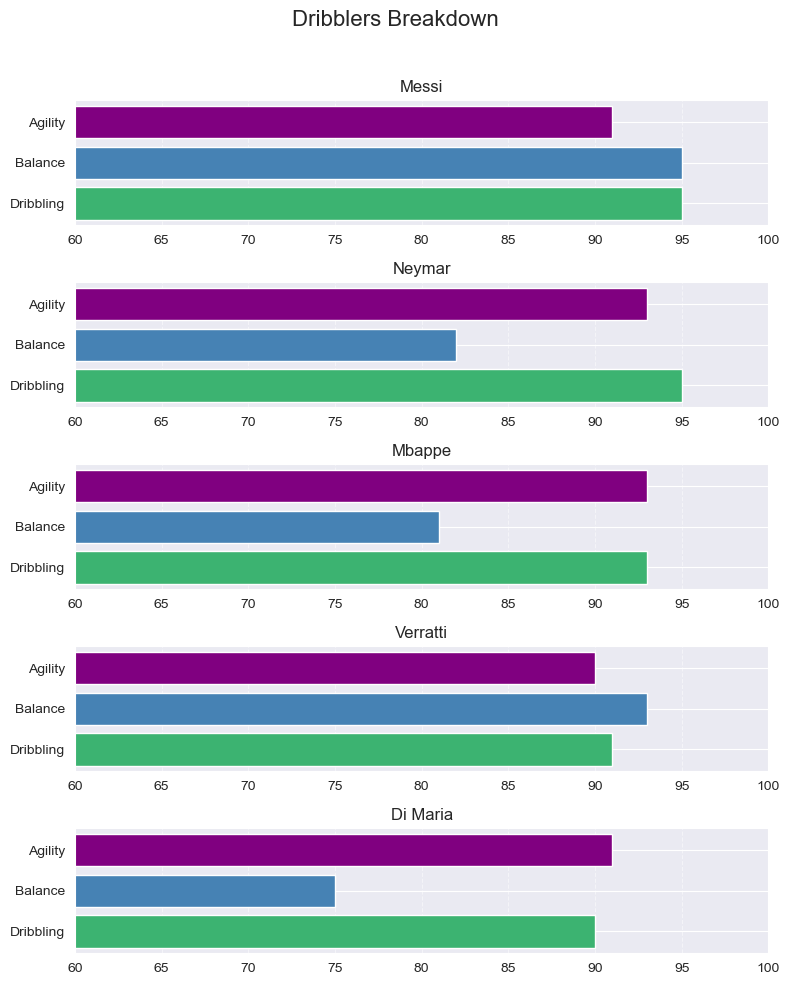

In [29]:
players = {
    'Messi':     [95, 95, 91],
    'Neymar':    [95, 82, 93],
    'Mbappe':    [93, 81, 93],
    'Verratti':  [91, 93, 90],
    'Di Maria':  [90, 75, 91]
}

attributes = ['Dribbling', 'Balance', 'Agility']

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(8, 10))
fig.suptitle('Dribblers Breakdown', fontsize=16)

for ax, (player, stats) in zip(axes, players.items()):
    ax.barh(attributes, stats, color=['mediumseagreen', 'steelblue', 'purple'])
    ax.set_xlim(60, 100)
    ax.set_title(player)
    ax.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Pass Masters 

In [30]:
top_pass =df[
    (df['vision'] >= 85) &
    (df['short_pass'] >= 85) & 
    (df['composure'] >= 85) & 
    (df['long_pass'] >= 80)    
][['player', 'club', 'vision', 'short_pass', 'long_pass', 'composure']] .sort_values('vision', ascending=False).head(10)
top_pass

,player,club,vision,short_pass,long_pass,composure
3555,Lionel Messi,Paris SG,94,91,90,96
4849,Kevin De Bruyne,Manchester City,94,93,93,88
635,Paul Pogba,Juventus,90,87,92,85
949,Parejo,Villarreal CF,90,92,90,85
5677,Neymar Jr,Paris SG,90,85,81,93
3120,Marco Verratti,Paris SG,89,90,89,94
3628,Angel Di Maria,Juventus,89,85,81,89
3535,Pedri,FC Barcelona,88,87,85,87
4438,Thiago,Liverpool,87,90,88,88
1534,Thomas Partey,Arsenal,85,85,85,87


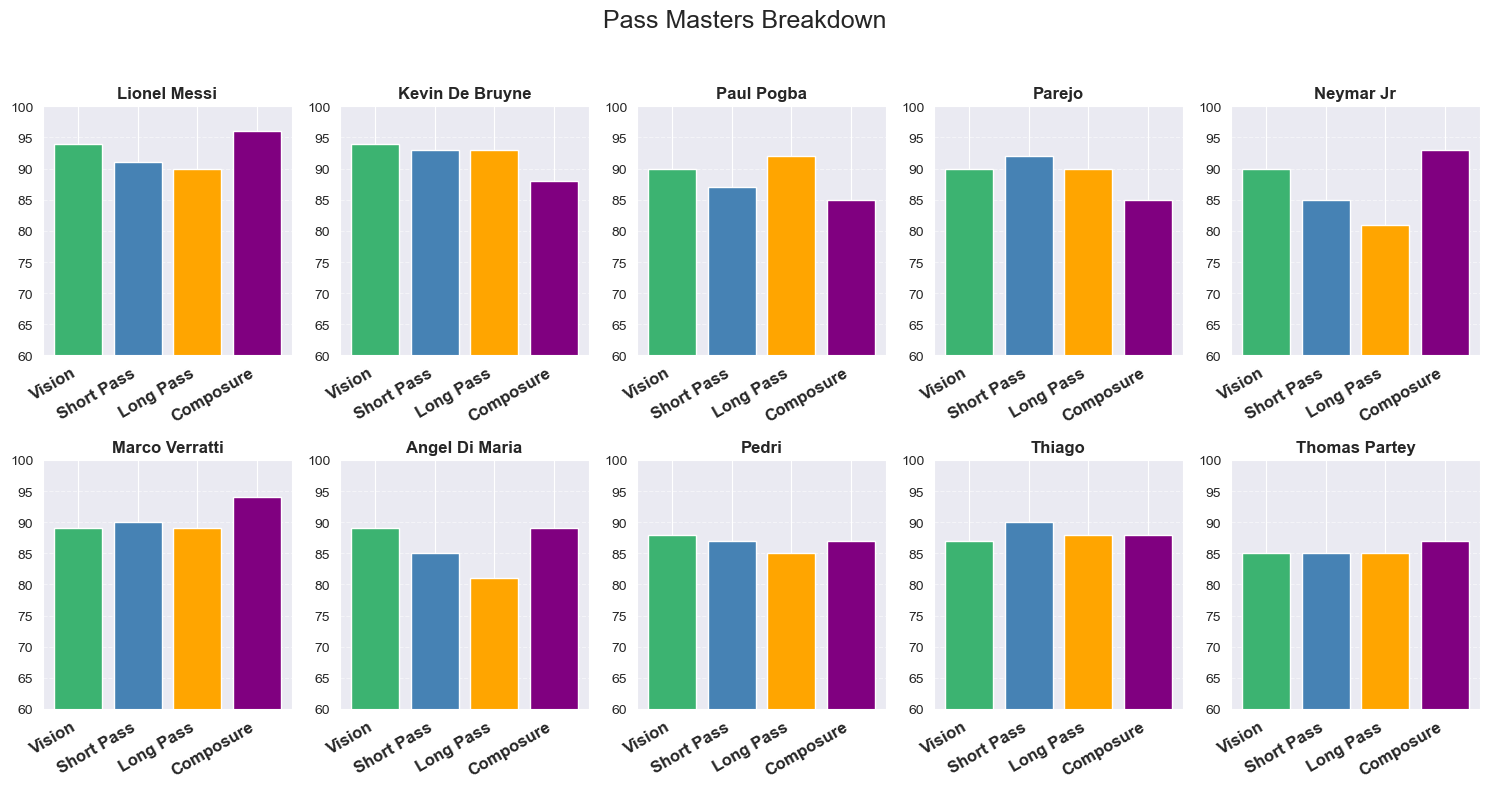

In [71]:
players = {
    "Lionel Messi":       [94, 91, 90, 96],
    "Kevin De Bruyne":    [94, 93, 93, 88],
    "Paul Pogba":         [90, 87, 92, 85],
    "Parejo":             [90, 92, 90, 85],
    "Neymar Jr":          [90, 85, 81, 93],
    "Marco Verratti":     [89, 90, 89, 94],
    "Angel Di Maria":     [89, 85, 81, 89],
    "Pedri":              [88, 87, 85, 87],
    "Thiago":             [87, 90, 88, 88],
    "Thomas Partey":      [85, 85, 85, 87]
}

attributes = ['Vision', 'Short Pass', 'Long Pass', 'Composure']
fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(15, 8))
fig.suptitle('Pass Masters Breakdown', fontsize=18)

axes = axes.flatten()


for ax, (player, stats) in zip(axes, players.items()):
    ax.bar(attributes, stats, color=['mediumseagreen', 'steelblue', 'orange', 'purple'])
    ax.set_ylim(60, 100)
    ax.set_title(player, fontsize=12,fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xticks(range(len(attributes)))
    ax.set_xticklabels(attributes, rotation=30, ha='right',fontweight='bold',fontsize=12)


plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Defensive

### Ball winners 

In [32]:
ball_winners = (
    df[
        (df['aggression'] >= 85) & 
        (df['stand_tackle'] >= 85) & 
        (df['strength'] >= 80)  
    ]
    [['player', 'club', 'aggression', 'stand_tackle', 'strength', 'interceptions']] 
    .sort_values('stand_tackle', ascending=False)  
)
ball_winners

,player,club,aggression,stand_tackle,strength,interceptions
4211,Virgil van Dijk,Liverpool,85,91,93,89
5368,Dayot Upamecano,FC Bayern München,89,86,88,78


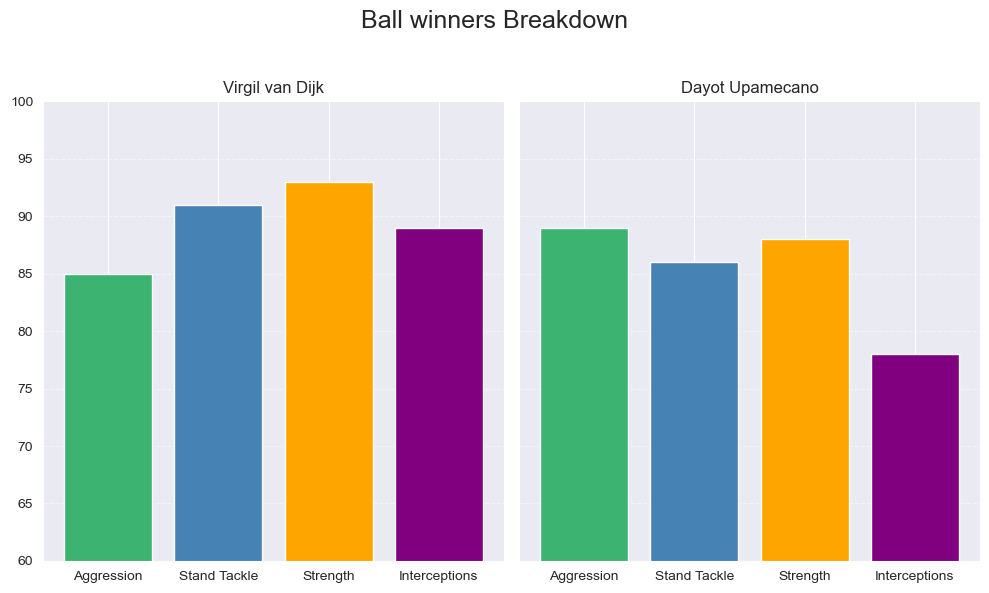

In [33]:
players = {
    'Virgil van Dijk': [85, 91, 93, 89],
    'Dayot Upamecano': [89, 86, 88, 78]
}
attributes = ['Aggression', 'Stand Tackle', 'Strength', 'Interceptions']

fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
fig.suptitle('Ball winners Breakdown', fontsize=18)

for ax, (player, stats) in zip(axes, players.items()):
    ax.bar(attributes, stats, color=['mediumseagreen', 'steelblue', 'orange', 'purple'])
    ax.set_ylim(60, 100)
    ax.set_title(player, fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.set_xticks(range(len(attributes)))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Silent_destroyers

In [34]:
silent_destroyers = (
    df[
        (df['interceptions'] >= 85) &  
        (df['composure'] >= 85) &      
        (df['reactions'] >= 85) &      
        (df['stand_tackle'] >= 80)     
    ]
    [['player', 'club', 'interceptions', 'composure', 'reactions', 'stand_tackle']]
    .sort_values(['interceptions', 'composure'], ascending=[False, False])  
)
silent_destroyers

,player,club,interceptions,composure,reactions,stand_tackle
4211,Virgil van Dijk,Liverpool,89,90,89,91
3120,Marco Verratti,Paris SG,86,94,87,82
5136,Joshua Kimmich,FC Bayern München,85,85,88,85


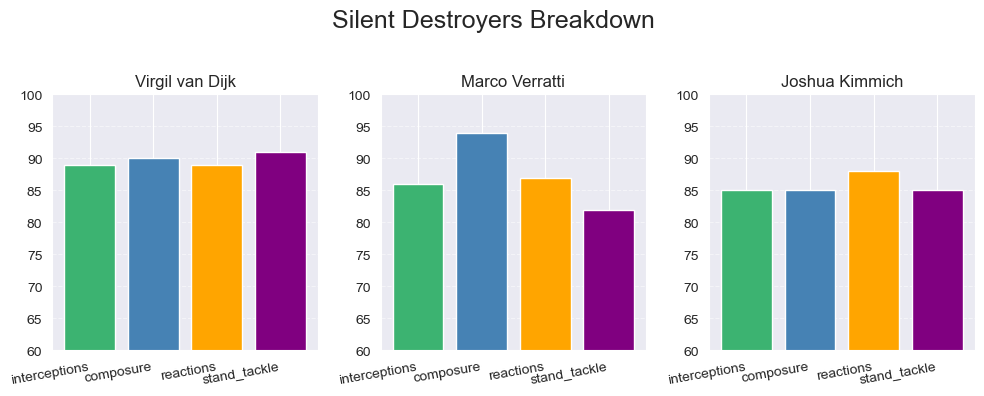

In [35]:
players = {
    'Virgil van Dijk': [89, 90, 89, 91],
    'Marco Verratti': [86, 94, 87, 82],
    'Joshua Kimmich': [85, 85, 88, 85]
}
attributes = ['interceptions', 'composure', 'reactions', 'stand_tackle']

fig, ax = plt.subplots(1, 3, figsize=(10, 4))
fig.suptitle(' Silent Destroyers Breakdown', fontsize=18)

for axis, (player, stats) in zip(ax, players.items()):
    axis.bar(attributes, stats, color=['mediumseagreen', 'steelblue', 'orange', 'purple'])
    axis.set_ylim(60, 100)
    axis.set_title(player, fontsize=12)
    axis.grid(axis='y', linestyle='--', alpha=0.5)
    axis.set_xticks(range(len(attributes)))
    axis.set_xticklabels(attributes, rotation=10, ha='right')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Shooting

### Strikers 

In [36]:
strikers = (
    df[
        (df['finishing'] >= 90) &  
        (df['att_position'] >= 85) &      
        (df['composure'] >= 85)         
]
    [['player', 'club', 'composure', 'att_position','finishing']]
    .sort_values('att_position',ascending=False)    
)
strikers

,player,club,composure,att_position,finishing
3555,Lionel Messi,Paris SG,96,93,90
5678,Cristiano Ronaldo,Al Nassr,94,93,91
1965,Erling Haaland,Manchester City,86,92,94
5229,Kylian Mbappe,Paris SG,88,92,93
5675,Karim Benzema,Real Madrid,90,92,92
5676,Mohamed Salah,Liverpool,90,91,92
4498,Iago Aspas,RC Celta,85,86,90


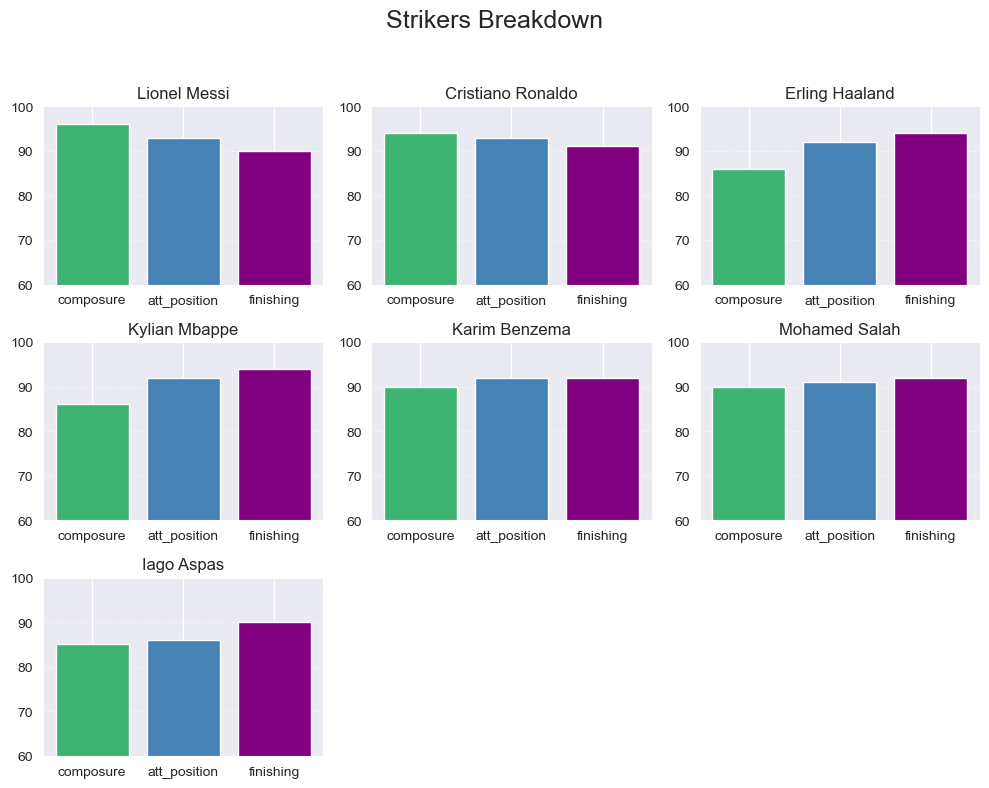

In [37]:
players = {
    'Lionel Messi': [96,93,90],
    'Cristiano Ronaldo': [94,93,91],
    'Erling Haaland': [86,92,94], 
    'Kylian Mbappe': [86,92,94],
    'Karim Benzema': [90,92,92],
    'Mohamed Salah': [90,91,92],
    'Iago Aspas': [85,86,90]
}

attributes = ['composure', 'att_position', 'finishing']

fig, ax = plt.subplots(3, 3, figsize=(10, 8))
fig.suptitle('Strikers Breakdown', fontsize=18)

axes = ax.flatten()

# Plot bars for each player
for axis, (player, stats) in zip(axes, players.items()):
    axis.bar(attributes, stats, color=['mediumseagreen', 'steelblue', 'purple'])
    axis.set_ylim(60, 100)
    axis.set_title(player, fontsize=12)
    axis.grid(axis='y', linestyle='--', alpha=0.5)

for i in range(len(players), len(axes)):
    fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Long shooters

In [38]:
long = (
    df[
        (df['long_shots'] >= 85) & 
        (df['shot_power'] >= 85) &   
        (df['curve'] >= 80) &        
        (df['finishing'] >= 75)      
    ]
    [['player', 'club', 'long_shots', 'shot_power', 'curve', 'finishing', 'vision']]
    .sort_values(['long_shots', 'shot_power'], ascending=[False, False])
)
long

,player,club,long_shots,shot_power,curve,finishing,vision
4849,Kevin De Bruyne,Manchester City,91,92,89,85,94
3555,Lionel Messi,Paris SG,91,86,93,90,94
3051,Bruno Fernandes,Manchester Utd,88,88,86,83,90
1991,Maximilian Arnold,VfL Wolfsburg,87,88,83,75,78


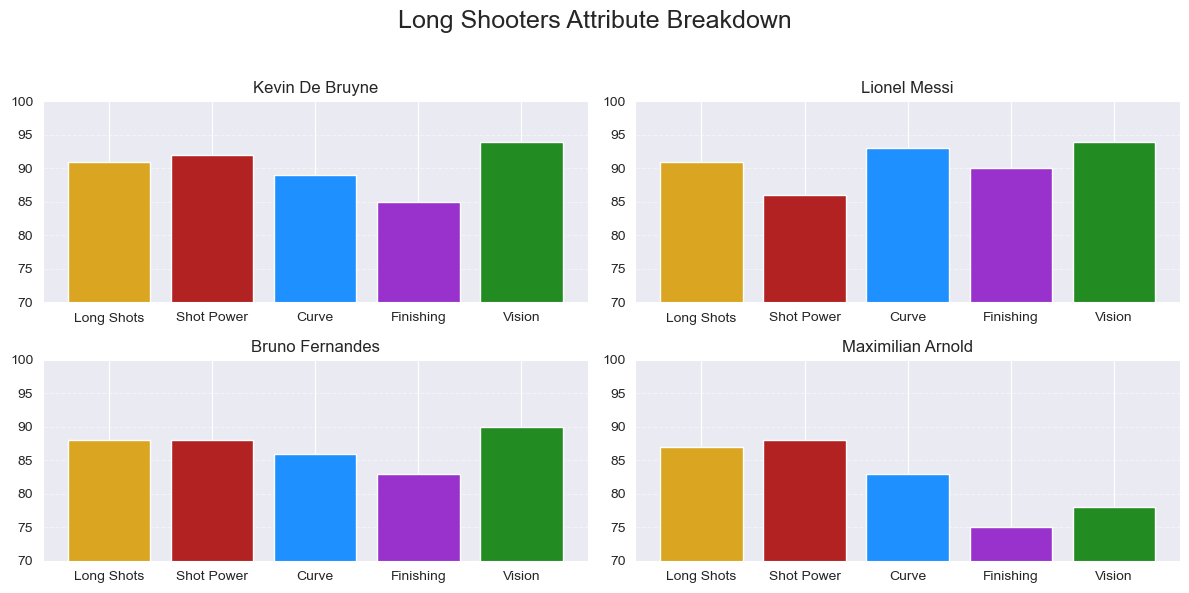

In [39]:
players = {
    'Kevin De Bruyne': [91, 92, 89, 85, 94],
    'Lionel Messi': [91, 86, 93, 90, 94],
    'Bruno Fernandes': [88, 88, 86, 83, 90],
    'Maximilian Arnold': [87, 88, 83, 75, 78]
}

attributes = ['Long Shots', 'Shot Power', 'Curve', 'Finishing', 'Vision']

fig, ax = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle('Long Shooters Attribute Breakdown', fontsize=18)

axes = ax.flatten()

for axis, (player, stats) in zip(axes, players.items()):
    axis.bar(attributes, stats, color=['goldenrod', 'firebrick', 'dodgerblue', 'darkorchid', 'forestgreen'])
    axis.set_ylim(70, 100)
    axis.set_title(player, fontsize=12)
    axis.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## Goalkeeping

### Elite GK's

In [40]:
# Filter only goalkeepers first 
gk_df = df[df['gk_diving'].notna()]  

elite_gk = (
    gk_df[
        (gk_df['gk_reflexes'] >= 80) &  
        (gk_df['gk_handling'] >= 80) &
        (gk_df['gk_positioning'] >= 75)
    ]
    [['player', 'club', 'gk_reflexes', 'gk_handling', 'gk_positioning']]
    .sort_values('gk_reflexes', ascending=False)
)
elite_gk

,player,club,gk_reflexes,gk_handling,gk_positioning
2458,Gianluigi Donnarumma,Paris SG,89,83,85
3119,Keylor Navas,Nott'm Forest,87,84,87
2763,Koen Casteels,VfL Wolfsburg,86,82,84
3451,Yassine Bounou,Sevilla FC,85,83,84
2384,Lucas Mantela,Brazil,81,87,77


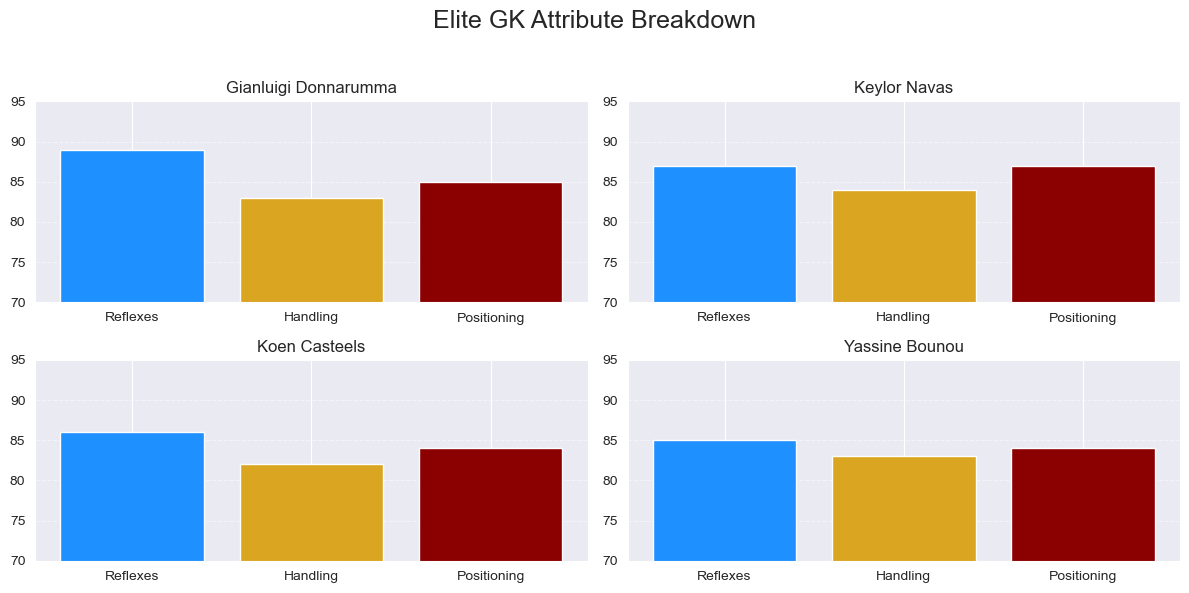

In [41]:
goalkeepers = {
    'Gianluigi Donnarumma': [89, 83, 85],
    'Keylor Navas': [87, 84, 87],
    'Koen Casteels': [86, 82, 84],
    'Yassine Bounou': [85, 83, 84]
}

attributes = ['Reflexes', 'Handling', 'Positioning']

fig, ax = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle('Elite GK Attribute Breakdown', fontsize=18)

axes = ax.flatten()

for axis, (player, stats) in zip(axes, goalkeepers.items()):
    axis.bar(attributes, stats, color=['dodgerblue', 'goldenrod', 'darkred'])
    axis.set_ylim(70, 95)
    axis.set_title(player, fontsize=12)
    axis.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

### Penalty Stoppers

In [42]:
penalty_specialists = (
    gk_df[
        (gk_df['gk_reflexes'] >= 85) &  
        (gk_df['gk_positioning'] >= 80) &  
        (gk_df['height'] >= 190)  
    ]
    [['player', 'club', 'gk_reflexes', 'gk_positioning', 'height', 'gk_diving']]
    .sort_values(['gk_reflexes', 'height'], ascending=[False, False])
    .head(10)
)
penalty_specialists

,player,club,gk_reflexes,gk_positioning,height,gk_diving
2458,Gianluigi Donnarumma,Paris SG,89,85,196,90
2763,Koen Casteels,VfL Wolfsburg,86,84,197,84
3451,Yassine Bounou,Sevilla FC,85,84,195,83


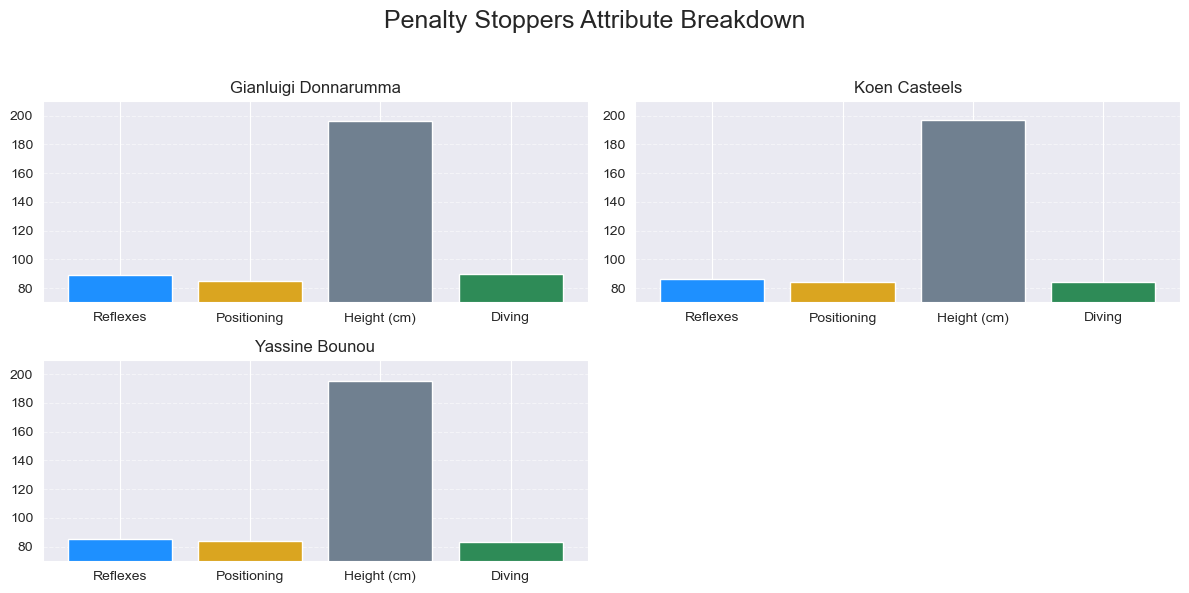

In [43]:
goalkeepers = {
    'Gianluigi Donnarumma': [89, 85, 196, 90],
    'Koen Casteels': [86, 84, 197, 84],
    'Yassine Bounou': [85, 84, 195, 83]
}

attributes = ['Reflexes', 'Positioning', 'Height (cm)', 'Diving']

fig, ax = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle('Penalty Stoppers Attribute Breakdown', fontsize=18)

axes = ax.flatten()

for axis, (player, stats) in zip(axes, goalkeepers.items()):
    axis.bar(attributes, stats, color=['dodgerblue', 'goldenrod', 'slategray', 'seagreen'])
    axis.set_ylim(70, 210) 
    axis.set_title(player, fontsize=12)
    axis.grid(axis='y', linestyle='--', alpha=0.5)

if len(goalkeepers) < len(axes):
    for i in range(len(goalkeepers), len(axes)):
        fig.delaxes(axes[i])

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Physical Traits

### Center Backs (CB)

In [44]:
CB = (
    df[
        (df['height'] >= 185) &  
        (df['jumping'] >= 85) &      
        (df['heading'] >= 85) &
        (df['strength'] >= 85)
]
    [['player', 'club', 'height', 'jumping','strength','heading']]
    .sort_values('strength',ascending=False)    
)
CB

,player,club,height,jumping,strength,heading
4211,Virgil van Dijk,Liverpool,193,88,93,86
731,Harry Maguire,Manchester Utd,193,87,90,85
943,Milan Pavkov,Al Fayha,193,92,89,86
2074,Luuk de Jong,PSV,189,90,87,93


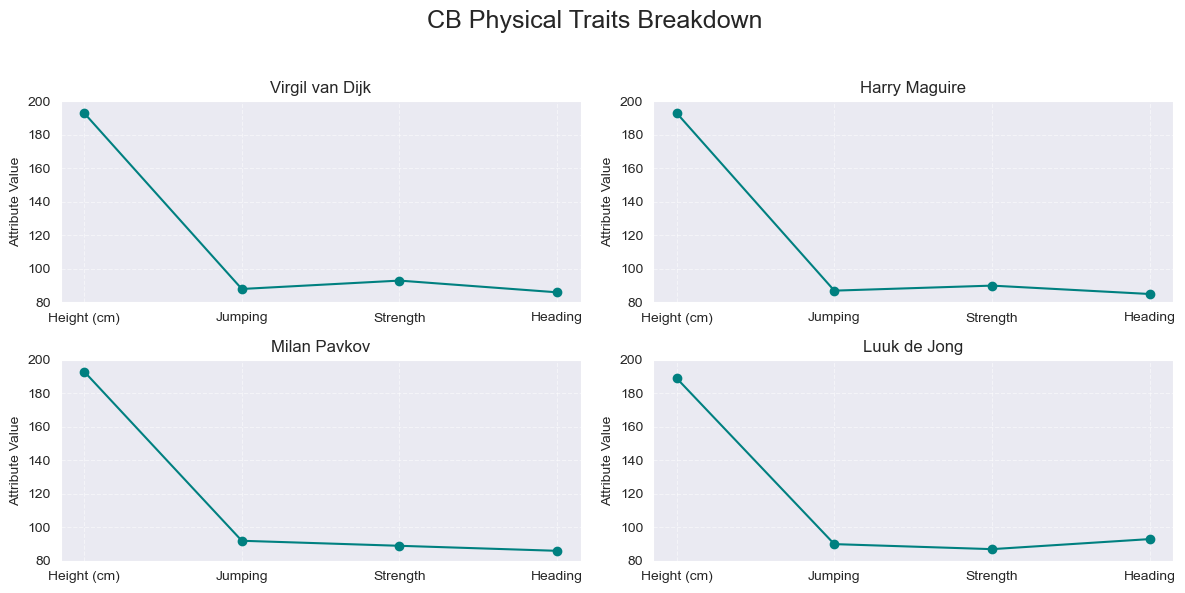

In [45]:
players = {
    'Virgil van Dijk': [193, 88, 93, 86],
    'Harry Maguire': [193, 87, 90, 85],
    'Milan Pavkov': [193, 92, 89, 86],
    'Luuk de Jong': [189, 90, 87, 93]
}

attributes = ['Height (cm)', 'Jumping', 'Strength', 'Heading']

fig, ax = plt.subplots(2, 2, figsize=(12, 6))
fig.suptitle('CB Physical Traits Breakdown', fontsize=18)

axes = ax.flatten()

for axis, (player, stats) in zip(axes, players.items()):
    axis.plot(attributes, stats, marker='o', linestyle='-', color='teal')
    axis.set_ylim(80, 200)
    axis.set_title(player, fontsize=12)
    axis.grid(True, linestyle='--', alpha=0.5)
    axis.set_ylabel('Attribute Value')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


barplots couldn't give us much clear picture of attribute so we used lineplot instead

### Wingers

In [46]:
wingers = (
    df[
        (df['sprint_speed'] >= 85) &  
        (df['acceleration'] >= 85) &  
        (df['agility'] >= 80) &       
        (df['dribbling'] >= 80)       
    ]
    [['player', 'club', 'sprint_speed', 'acceleration', 'dribbling', 'crossing']]  
    .sort_values(['sprint_speed', 'dribbling'], ascending=[False, False])
    .head(10)  
)
wingers

,player,club,sprint_speed,acceleration,dribbling,crossing
5229,Kylian Mbappe,Paris SG,97,97,93,78
4496,Galeno,FC Porto,93,91,83,68
5175,Hirving Lozano,Napoli FC,93,92,83,73
143,Kamaldeen Sulemana,Southampton,93,92,80,64
5188,Rafael Leao,Milan,92,90,89,75
4052,Leroy Sane,FC Bayern München,92,88,86,81
4627,Leon Bailey,Aston Villa,92,93,84,73
1793,Nico Williams,Athletic Club,92,92,83,73
3770,Federico Chiesa,Juventus,91,91,89,75
2693,Wilfried Zaha,Crystal Palace,91,88,88,75


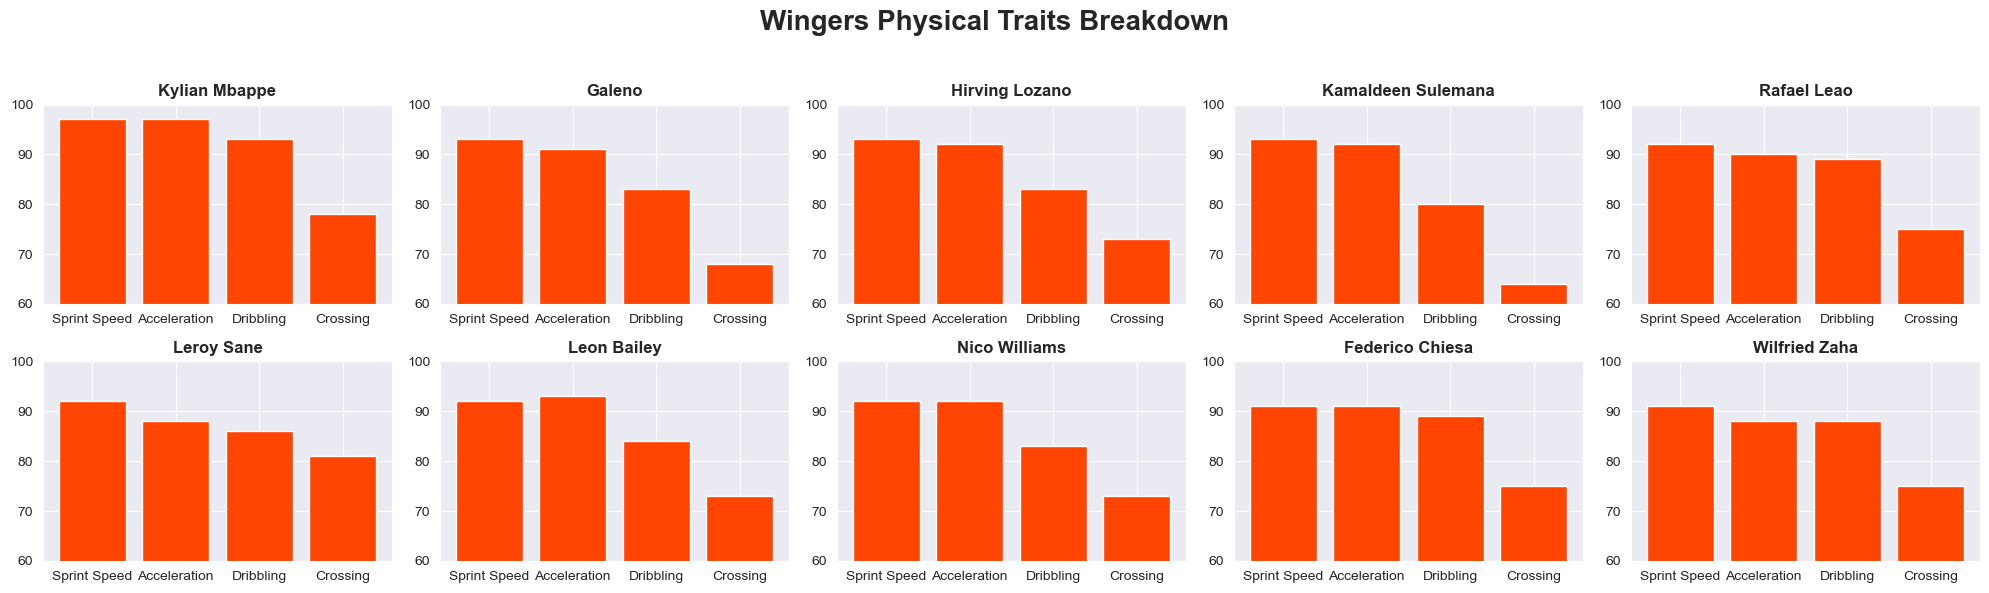

In [98]:
players = {
    'Kylian Mbappe': [97, 97, 93, 78],
    'Galeno': [93, 91, 83, 68],
    'Hirving Lozano': [93, 92, 83, 73],
    'Kamaldeen Sulemana': [93, 92, 80, 64],
    'Rafael Leao': [92, 90, 89, 75],
    'Leroy Sane': [92, 88, 86, 81],
    'Leon Bailey': [92, 93, 84, 73],
    'Nico Williams': [92, 92, 83, 73],
    'Federico Chiesa': [91, 91, 89, 75],
    'Wilfried Zaha': [91, 88, 88, 75]
}

attributes = ['Sprint Speed', 'Acceleration', 'Dribbling', 'Crossing']

fig, ax = plt.subplots(2, 5, figsize=(20, 6))
fig.suptitle('Wingers Physical Traits Breakdown', fontsize=20,fontweight='bold')

axes = ax.flatten()

for axis, (player, stats) in zip(axes, players.items()):
    axis.bar(attributes, stats, color='orangered')
    axis.set_ylim(60, 100)
    axis.set_title(player, fontsize=12,fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


### Young Talents

In [48]:
young_gems = (
    df[
        (df['age'] < 23) & 
        (df['acceleration'] >= 85) &  
        (df['ball_control'] >= 80) &      
        (df['value'] >= 10_000_000)   
    ]
    [[
        'player', 'club', 'age', 
        'acceleration', 'ball_control', 'dribbling',
        'vision', 'value'
    ]]
    .sort_values(['value', 'acceleration'], ascending=[False, False])
)
young_gems

,player,club,age,acceleration,ball_control,dribbling,vision,value
961,Bukayo Saka,Arsenal,21,88,85,88,83,47500000.0
4247,Rodrygo,Real Madrid,22,88,83,84,73,30500000.0
5644,Gabriel Martinelli,Arsenal,22,89,82,88,75,25000000.0
3671,Gonzalo Plata,R. Valladolid CF,22,90,82,82,73,12500000.0
2496,Callum Hudson-Odoi,Leverkusen,22,86,81,82,74,12500000.0


In [49]:
df.dtypes

player             object
country            object
height              int64
weight              int64
age                 int64
club               object
ball_control        int64
dribbling           int64
marking           float64
slide_tackle        int64
stand_tackle        int64
aggression          int64
reactions           int64
att_position        int64
interceptions       int64
vision              int64
composure           int64
crossing            int64
short_pass          int64
long_pass           int64
acceleration        int64
stamina             int64
strength            int64
balance             int64
sprint_speed        int64
agility             int64
jumping             int64
heading             int64
shot_power          int64
finishing           int64
long_shots          int64
curve               int64
fk_acc              int64
penalties           int64
volleys             int64
gk_positioning      int64
gk_diving           int64
gk_handling         int64
gk_kicking  

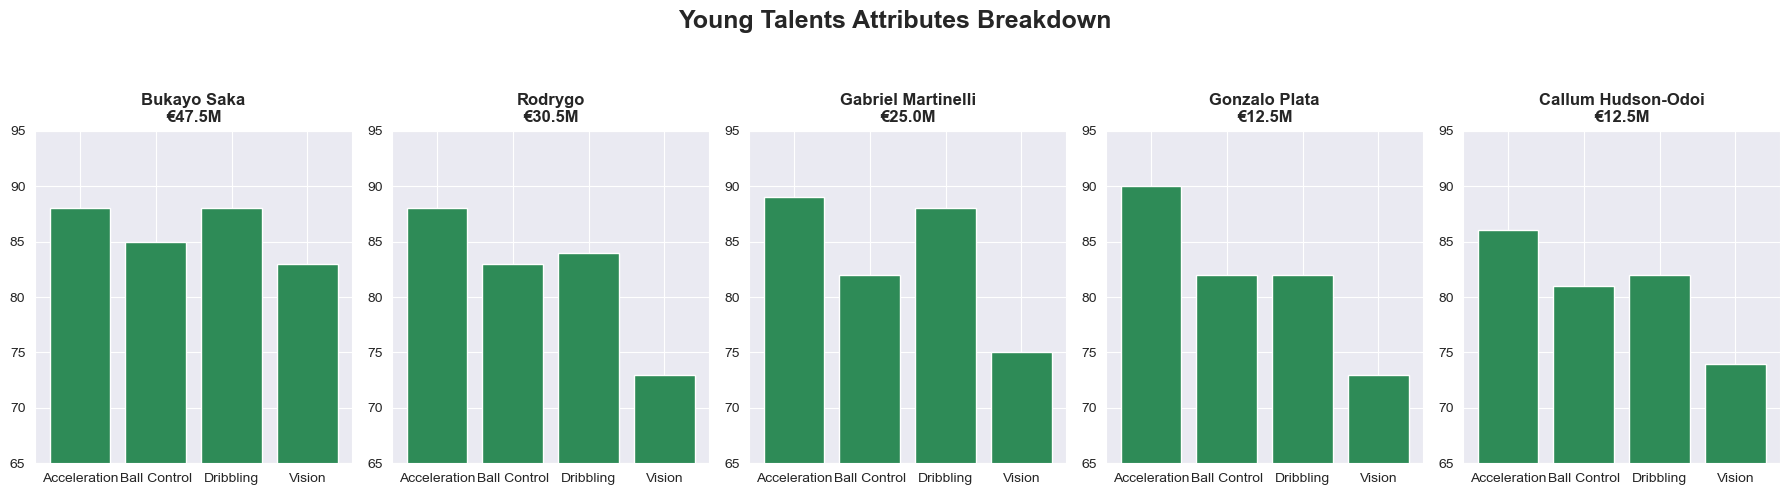

In [96]:
players = {
    'Bukayo Saka': [88, 85, 88, 83],
    'Rodrygo': [88, 83, 84, 73],
    'Gabriel Martinelli': [89, 82, 88, 75],
    'Gonzalo Plata': [90, 82, 82, 73],
    'Callum Hudson-Odoi': [86, 81, 82, 74]
}

values = {
    'Bukayo Saka': 47.5,
    'Rodrygo': 30.5,
    'Gabriel Martinelli': 25.0,
    'Gonzalo Plata': 12.5,
    'Callum Hudson-Odoi': 12.5
}

attributes = ['Acceleration', 'Ball Control', 'Dribbling', 'Vision']

fig, axs = plt.subplots(1, 5, figsize=(18, 5))
fig.suptitle('Young Talents Attributes Breakdown', fontsize=18,fontweight='bold')

for ax, (player, stats) in zip(axs, players.items()):
    ax.bar(attributes, stats, color='seagreen')
    ax.set_ylim(65, 95)
    ax.set_title(f"{player}\n€{values[player]}M", fontsize=12,fontweight='bold')
    
plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()


### Set-Piece Wizards

In [51]:
set_piece_masters = (
    df[
        (df['fk_acc'] >= 85) &       
        (df['curve'] >= 85) &        
        (df['long_pass'] >= 80) &    
        (df['vision'] >= 80)         
    ]
    [[
        'player', 'club', 'age',
        'fk_acc', 'curve', 'long_pass', 
        'penalties', 'vision'
    ]]
    .sort_values(['fk_acc', 'curve'], ascending=[False, False])
)
set_piece_masters

,player,club,age,fk_acc,curve,long_pass,penalties,vision
3239,James Ward-Prowse,Southampton,28,94,93,84,77,82
3555,Lionel Messi,Paris SG,36,93,93,90,75,94
949,Parejo,Villarreal CF,34,90,88,90,88,90
3628,Angel Di Maria,Juventus,35,88,92,81,73,89
5677,Neymar Jr,Paris SG,31,87,88,81,91,90
2330,Antoine Griezmann,Atlético de Madrid,32,85,87,81,79,87
3051,Bruno Fernandes,Manchester Utd,28,85,86,87,90,90


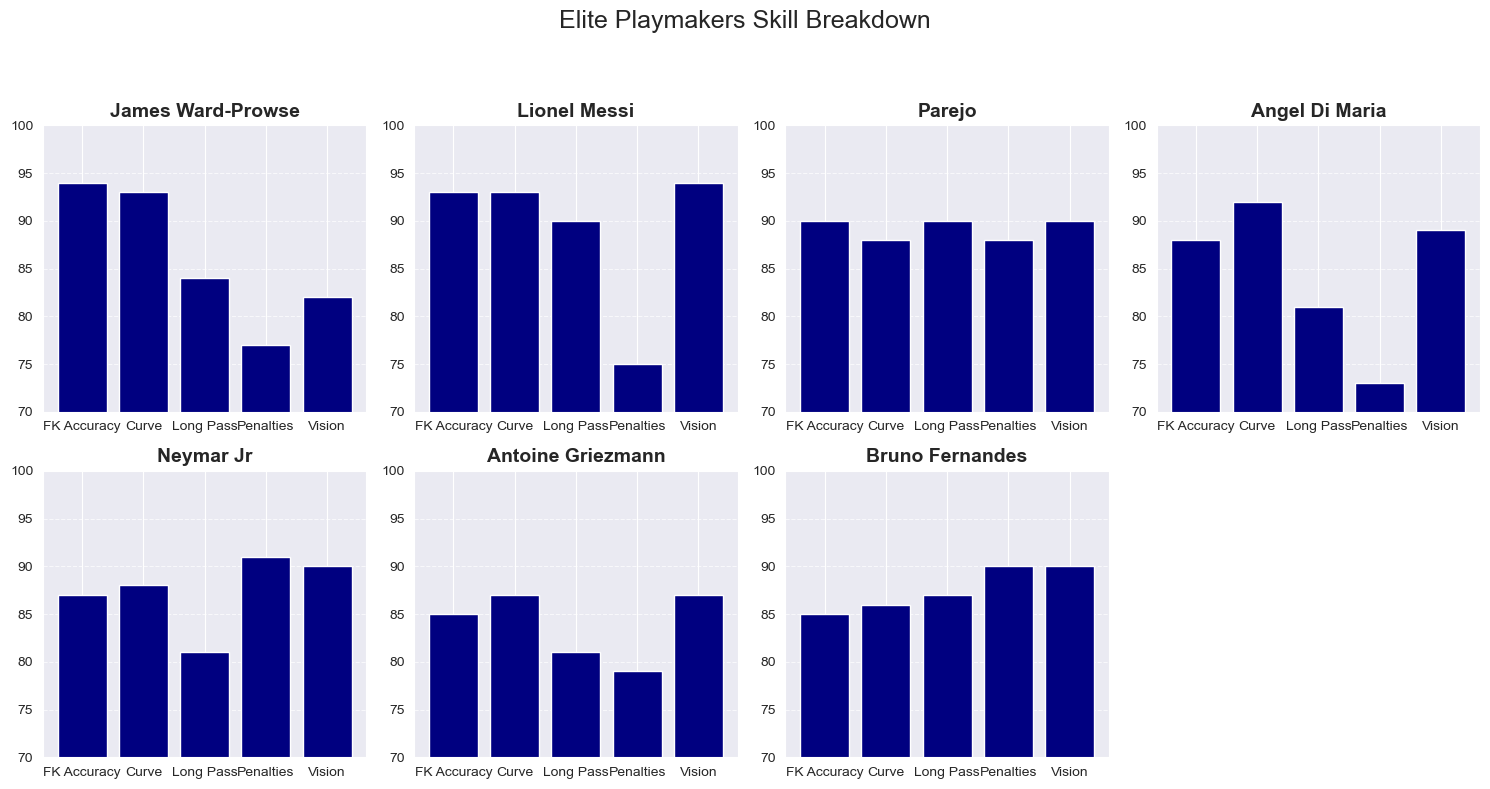

In [81]:
players = {
    'James Ward-Prowse': [94, 93, 84, 77, 82],
    'Lionel Messi': [93, 93, 90, 75, 94],
    'Parejo': [90, 88, 90, 88, 90],
    'Angel Di Maria': [88, 92, 81, 73, 89],
    'Neymar Jr': [87, 88, 81, 91, 90],
    'Antoine Griezmann': [85, 87, 81, 79, 87],
    'Bruno Fernandes': [85, 86, 87, 90, 90]
}

attributes = ['FK Accuracy', 'Curve', 'Long Pass', 'Penalties', 'Vision']

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(15, 8))
fig.suptitle('Elite Playmakers Skill Breakdown', fontsize=18)

axs = axs.flatten()

for i, (player, stats) in enumerate(players.items()):
    axs[i].bar(attributes, stats, color='navy')
    axs[i].set_ylim(70, 100)
    axs[i].set_title(player, fontsize=14,fontweight='bold')
    axs[i].grid(True, axis='y', linestyle='--', alpha=0.7)
    
    

for j in range(len(players), len(axs)):
    axs[j].axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()


### Complete Players

In [53]:
complete_players = (
    df[
        (df['ball_control'] > 75) &
        (df['dribbling'] > 75) &
        (df['short_pass'] > 75) &
        (df['stand_tackle'] > 75) &
        (df['strength'] > 75) &
        (df['stamina'] > 75) &
        (df['value'] < 20_000_000)  
    ]
    [[
        'player', 'club', 'age', 'value',
        'ball_control', 'dribbling', 'short_pass',
        'stand_tackle', 'strength', 'stamina'
    ]]
    .sort_values(['value', 'age'], ascending=[True, True])  
)
complete_players

,player,club,age,value,ball_control,dribbling,short_pass,stand_tackle,strength,stamina
5016,Abdoulaye Doucoure,Everton,30,10500000.0,79,77,76,79,81,85
1773,Francis Coquelin,Villarreal CF,32,17500000.0,81,80,84,79,80,76
740,Salih Ozcan,Borussia Dortmund,25,18000000.0,76,77,78,76,80,83


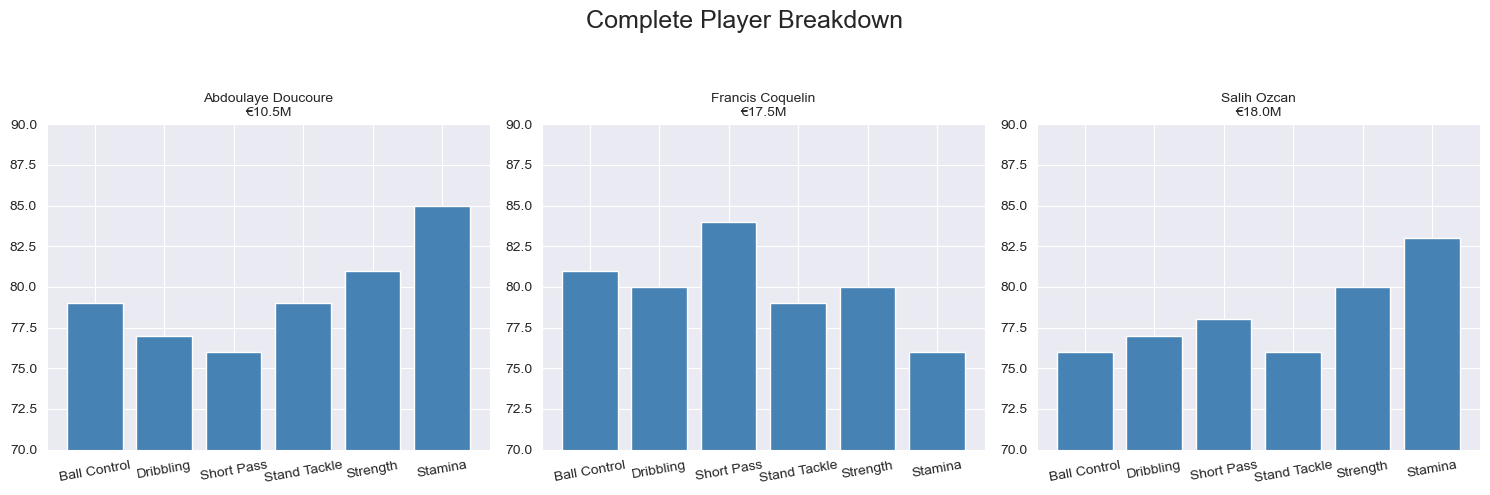

In [54]:
players = {
    'Abdoulaye Doucoure': [79, 77, 76, 79, 81, 85],
    'Francis Coquelin': [81, 80, 84, 79, 80, 76],
    'Salih Ozcan': [76, 77, 78, 76, 80, 83]
}

values = {
    'Abdoulaye Doucoure': 10.5,
    'Francis Coquelin': 17.5,
    'Salih Ozcan': 18.0
}

attributes = ['Ball Control', 'Dribbling', 'Short Pass', 'Stand Tackle', 'Strength', 'Stamina']

# Plot
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Complete Player Breakdown', fontsize=18)

for ax, (player, stats) in zip(axs, players.items()):
    ax.bar(attributes, stats, color='steelblue')
    ax.set_ylim(70, 90)
    ax.set_title(f"{player}\n€{values[player]}M", fontsize=10)
    ax.tick_params(axis='x', labelrotation=10)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

# Correlation 
Correlation shows the strength and direction of relationships between numerical variables. Values range from -1 to 1 — where 1 means a strong positive relation, -1 means strong negative, and 0 means no correlation. We use a heatmap to visually spot which features are most related.


In [55]:
# Make a new dataframe with only numeric values, because correaltion only works on numeric data not categorical 
numeric_df = df.drop(columns=['player', 'country', 'club'])

In [56]:
corr_numeric = numeric_df.corr()

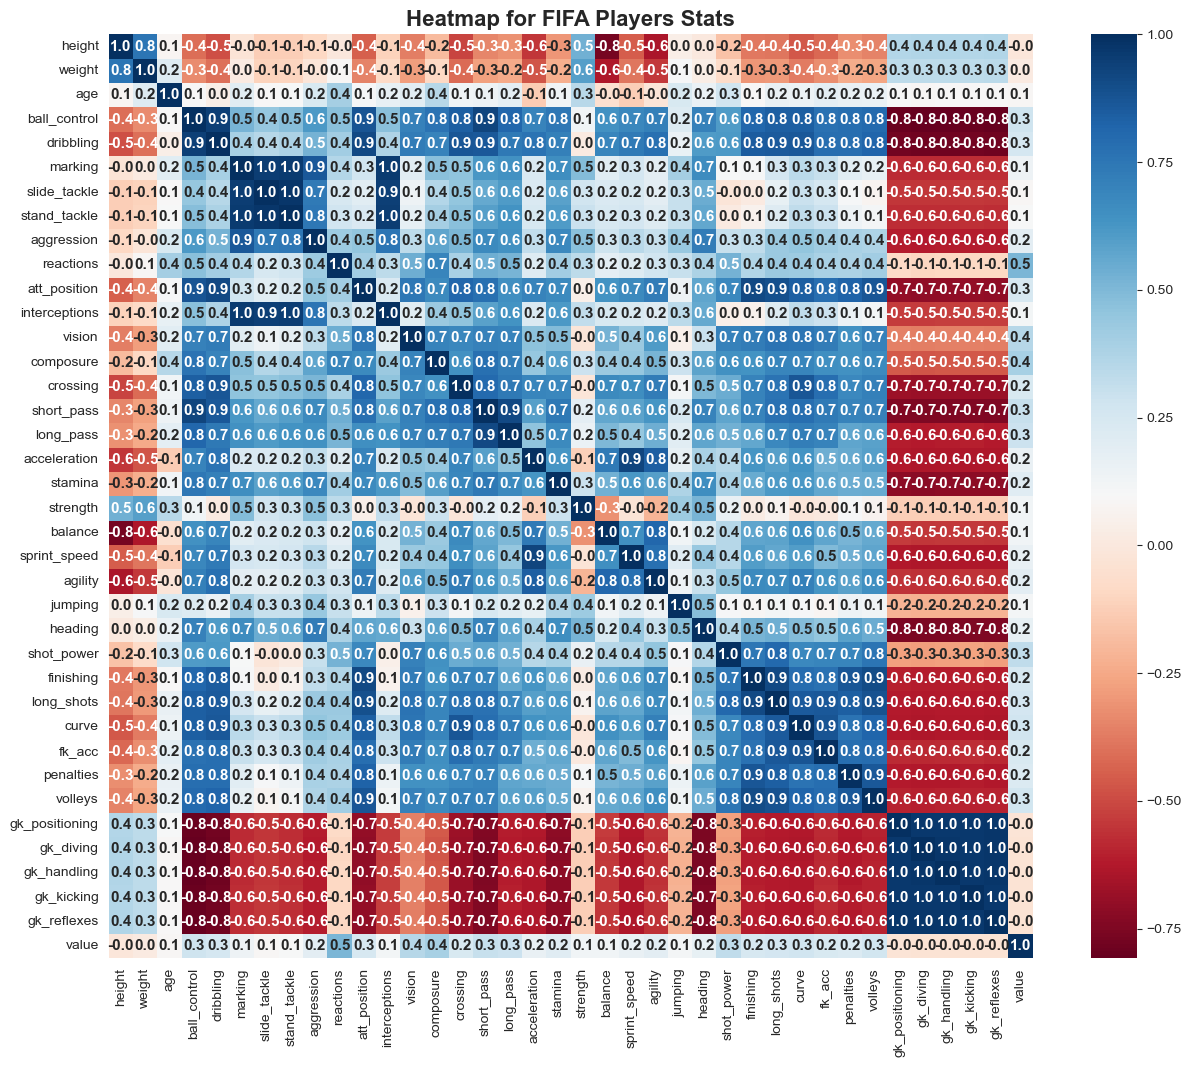

In [57]:
# Plot a heatmap
plt.figure(figsize=(15,12))
sns.heatmap(data=corr_numeric,cmap='RdBu',annot=True,annot_kws={'fontsize':11,'fontweight':'bold'},square=True,fmt='.1f')
plt.title('Heatmap for FIFA Players Stats',fontsize=16,fontweight='bold')
plt.show()

conclusion: 
We observed several relationships among numerical variables, but here are a few key highlights to understand how to read a heatmap:

- **`height` vs `value`** → `0.0`  
  No correlation exists — a player's height does not impact their market value.

- **`height` vs `gk_reflexes`** → `0.4`  
  Moderate positive correlation — taller players tend to have slightly better reflexes, possibly goalkeepers.

- **`height` vs `weight`** → `0.8`  
  Strong positive correlation — taller players usually weigh more, showing a natural body proportion pattern.


# Bivariate Analysis 
## Categorical -- Numerical 
- Countries Producing U18 Players (Top 10)
- Most Valued Club  (Top 10)
- Most Valued Players (Top 10)
- Oldest player (Top 10)
- player with highest finishing rate (Top 10)
- player with highest strength (Top 10)
## Numerical -- Numerical 
- height -- weight
- age -- value
- dribbling -- ball control
- vision -- short pass
- sprint speed -- acceleration
- heading -- jumping

there are so many columns but we picked only the most useful and insightful ones for our work, more columns can be visualized in future but for pracitce purpose right now these are enough

## Categorical Vs Numerical 

### Countries Producing U18 Players (Top 10)

In [58]:
young_players = df[df['age'] < 18]
country_avg_value = young_players.groupby('country')['value'].mean().reset_index()
top_10_countries = country_avg_value.sort_values(by='value',ascending=False).head(10)
top_10_countries

,country,value
10,Sweden,72500.0
8,Scotland,23000.0
3,Germany,22000.0
0,Australia,16000.0
6,Republic of Ireland,13500.0
1,Belgium,13000.0
7,Romania,13000.0
9,Spain,12000.0
5,Norway,11000.0
4,Italy,8000.0


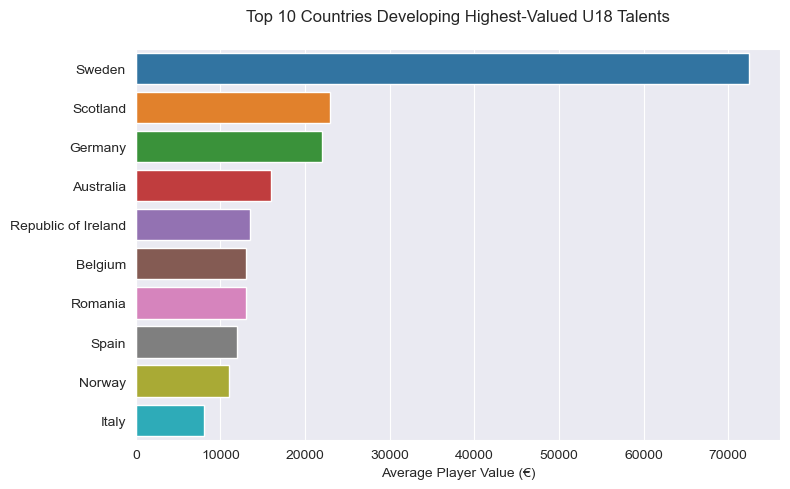

In [59]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
plt.title("Top 10 Countries Developing Highest-Valued U18 Talents", pad=20)
sns.barplot(data=top_10_countries, x='value', y='country',hue='country')
plt.xlabel("Average Player Value (€)")
plt.ylabel("")  
plt.tight_layout()

### Most Valued Club (Top 10)

In [60]:
club_value = df.groupby('club')['value'].sum().reset_index()
top_club = club_value.sort_values(by='value',ascending=False).head(10)
top_club

,club,value
394,Manchester City,427033500.0
209,FC Bayern München,409543000.0
454,Paris SG,400725000.0
395,Manchester Utd,348327500.0
383,Liverpool,314188500.0
58,Arsenal,273935500.0
100,Brazil,215000000.0
138,Chelsea,213560000.0
67,Atlético de Madrid,197750000.0
207,FC Barcelona,186345000.0


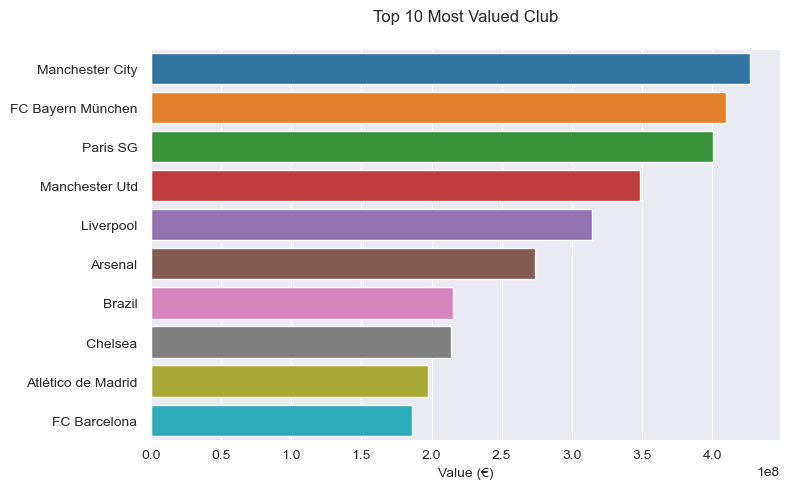

In [61]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
plt.title("Top 10 Most Valued Club", pad=20)
sns.barplot(data=top_club, x='value', y='club',hue='club')
plt.xlabel("Value (€)")
plt.ylabel("") 
plt.tight_layout()

### Most Valued Players (Top 10)

In [62]:
highest_paid = df[['player','value']].sort_values(by='value',ascending=False).head(10)
highest_paid

,player,value
5229,Kylian Mbappe,153500000.0
1965,Erling Haaland,123000000.0
4849,Kevin De Bruyne,107500000.0
916,Sadio Mane,101000000.0
5677,Neymar Jr,99500000.0
5676,Mohamed Salah,99500000.0
5136,Joshua Kimmich,97000000.0
4211,Virgil van Dijk,84500000.0
3416,Lautaro Martinez,79500000.0
2458,Gianluigi Donnarumma,78000000.0


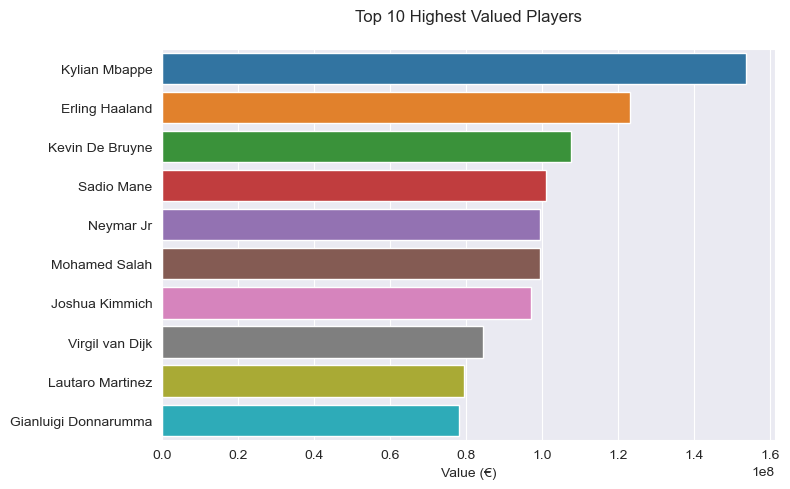

In [63]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
plt.title("Top 10 Highest Valued Players", pad=20)
sns.barplot(data=highest_paid, x='value', y='player',hue='player')
plt.xlabel("Value (€)")
plt.ylabel("")  
plt.tight_layout()

### Oldest player (Top 10)

most players in football/soccer are considered old when you reach 30s so we'll use >=30 condition to filter out top 10 oldest players 

In [64]:
filter_old = df[df['age'] >= 30]
old_players = filter_old.sort_values(by='age', ascending=False).head(10)
old_players[['player', 'age']]

,player,age
5679,Zlatan Ibrahimovi?,41
1574,Antolin Alcaraz,41
3930,Pepe Reina,41
5409,Enrique Bologna,41
4422,Diego Lopez,41
4361,Thomas Mikkelsen,40
4282,Claudio Bravo,40
4002,Alessandro Diamanti,40
1796,Federico Marchetti,40
3785,Mariano Andujar,40


### player with highest finishing rate (Top 10)

In [65]:
finish = df[df['finishing']>85]
top_finish = finish.sort_values(by='finishing',ascending=False).head(10)
top_finish[['player','finishing']]

,player,finishing
1965,Erling Haaland,94
5229,Kylian Mbappe,93
5675,Karim Benzema,92
5676,Mohamed Salah,92
5678,Cristiano Ronaldo,91
3555,Lionel Messi,90
4498,Iago Aspas,90
329,Gerard Moreno,89
857,Romelu Lukaku,88
3416,Lautaro Martinez,88


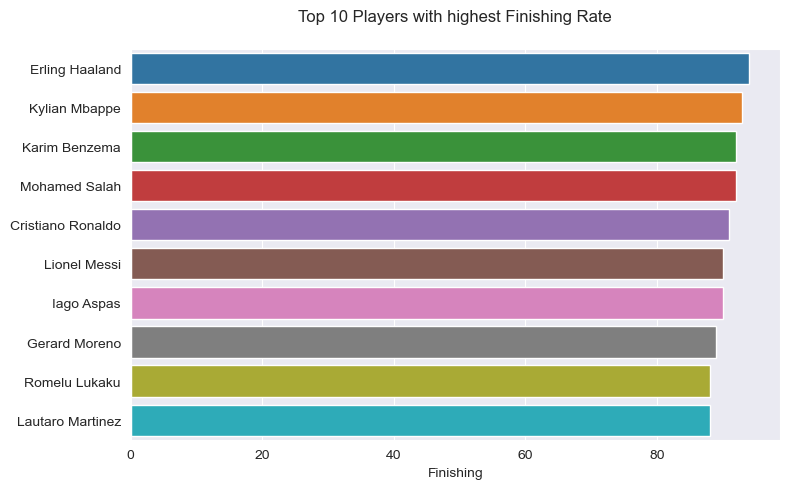

In [66]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
plt.title("Top 10 Players with highest Finishing Rate", pad=20)
sns.barplot(data=top_finish, x='finishing', y='player',hue='player')
plt.xlabel("Finishing")
plt.ylabel("")  
plt.tight_layout()

### player with highest strength (Top 10)

In [67]:
strength = df[df['strength']>85]
top_strength = strength.sort_values(by='strength',ascending=False).head(10)
top_strength[['player','strength']]

,player,strength
2575,Tomas Chory,96
857,Romelu Lukaku,95
2218,Tomas Petrasek,95
607,Sebastian Mai,93
39,Kalidou Koulibaly,93
1965,Erling Haaland,93
4211,Virgil van Dijk,93
549,Ricardo Santos,93
718,Christian Luyindama,93
3407,Pedrao Tofico,93


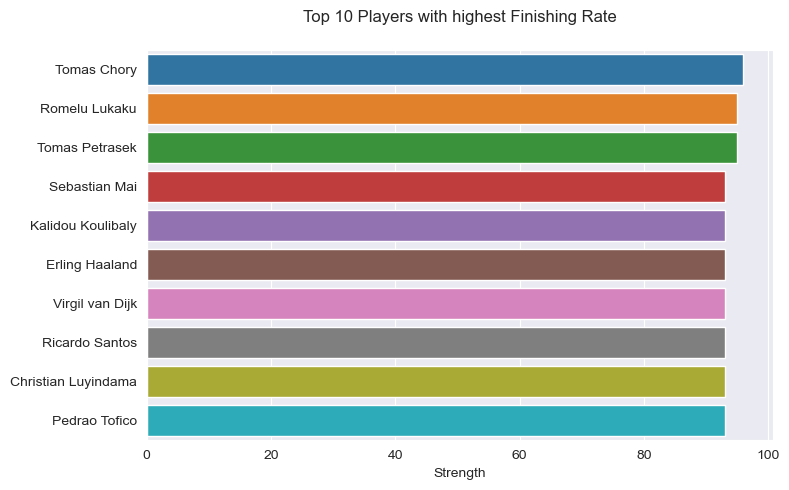

In [68]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
plt.title("Top 10 Players with highest Finishing Rate", pad=20)
sns.barplot(data=top_strength, x='strength', y='player',hue='player')
plt.xlabel("Strength")
plt.ylabel("")  
plt.tight_layout()

## Numerical vs Numerical 

### Height -- Weight 

Text(36.142508680555565, 0.5, 'Weight')

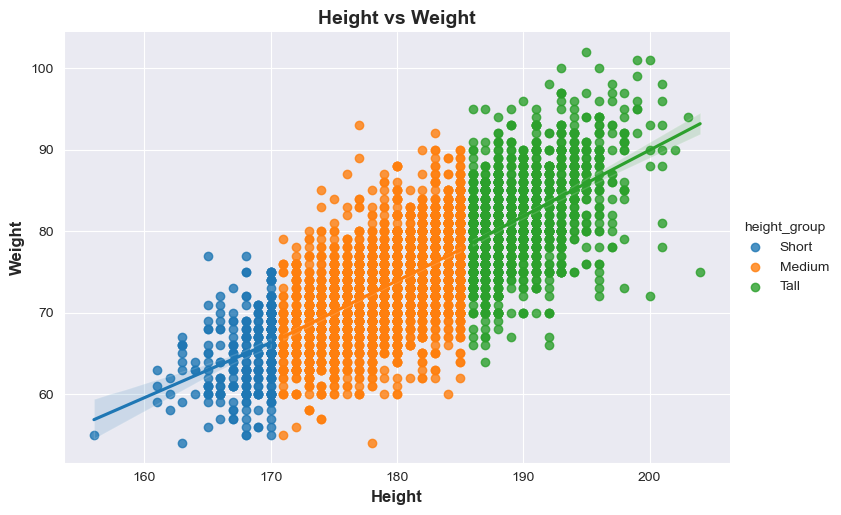

In [109]:
df['height_group'] = pd.cut(df['height'], bins=[150, 170, 185, 205], labels=['Short', 'Medium', 'Tall'])

sns.set_style('darkgrid')
sns.lmplot(data=df, x='height', y='weight', hue='height_group', height=5, aspect=1.5)
plt.title("Height vs Weight",fontsize=14,fontweight='bold')
plt.xlabel("Height",fontsize=12,fontweight='bold')
plt.ylabel("Weight",fontsize=12,fontweight='bold')

short player seem to have less weight and Tall players seem to weigh more 

### age -- value

Text(0, 0.5, 'Value')

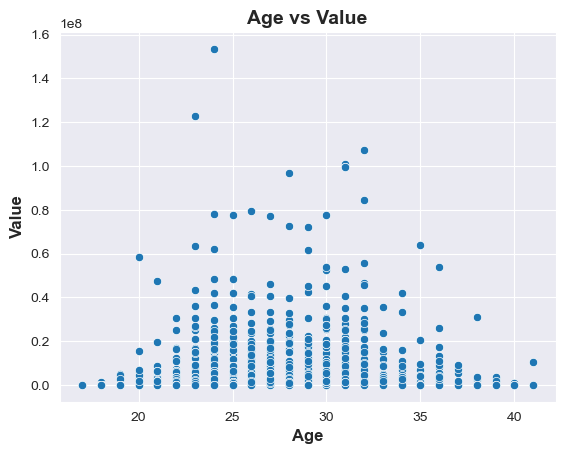

In [123]:
sns.set_style('darkgrid')
sns.scatterplot(data=df, x='age', y='value')
plt.title("Age vs Value",fontsize=14,fontweight='bold')
plt.xlabel("Age",fontsize=12,fontweight='bold')
plt.ylabel("Value",fontsize=12,fontweight='bold')

### dribbling -- ball control

Text(35.08024305555556, 0.5, 'Ball Control')

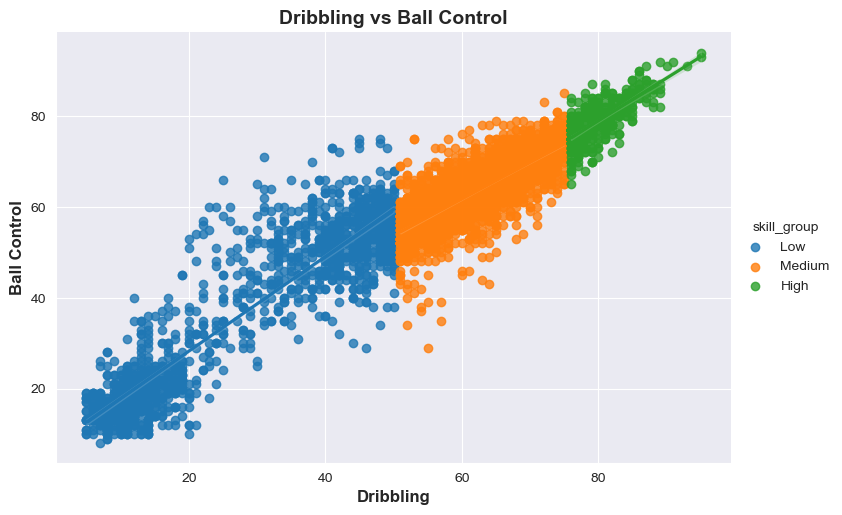

In [125]:
df['skill_group'] = pd.cut(df['dribbling'], bins=[0, 50, 75, 100], labels=['Low', 'Medium', 'High'])

sns.set_style('darkgrid')
sns.lmplot(data=df,x='dribbling',y='ball_control',hue='skill_group',height=5,aspect=1.5)
plt.title("Dribbling vs Ball Control", fontsize=14, fontweight='bold')
plt.xlabel("Dribbling", fontsize=12, fontweight='bold')
plt.ylabel("Ball Control", fontsize=12, fontweight='bold')

### vision -- short pass

Text(35.115633680555554, 0.5, 'Short Pass')

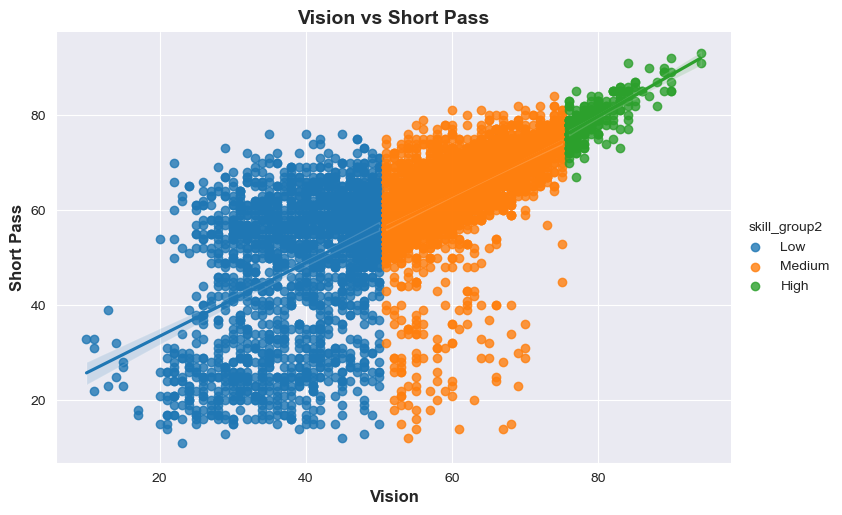

In [126]:
df['skill_group2'] = pd.cut(df['vision'], bins=[0, 50, 75, 100], labels=['Low', 'Medium', 'High'])

sns.set_style('darkgrid')
sns.lmplot(data=df,x='vision',y='short_pass',hue='skill_group2',height=5,aspect=1.5)
plt.title("Vision vs Short Pass", fontsize=14, fontweight='bold')
plt.xlabel("Vision", fontsize=12, fontweight='bold')
plt.ylabel("Short Pass", fontsize=12, fontweight='bold')

### sprint speed -- acceleration

Text(35.68243055555557, 0.5, 'Acceleration')

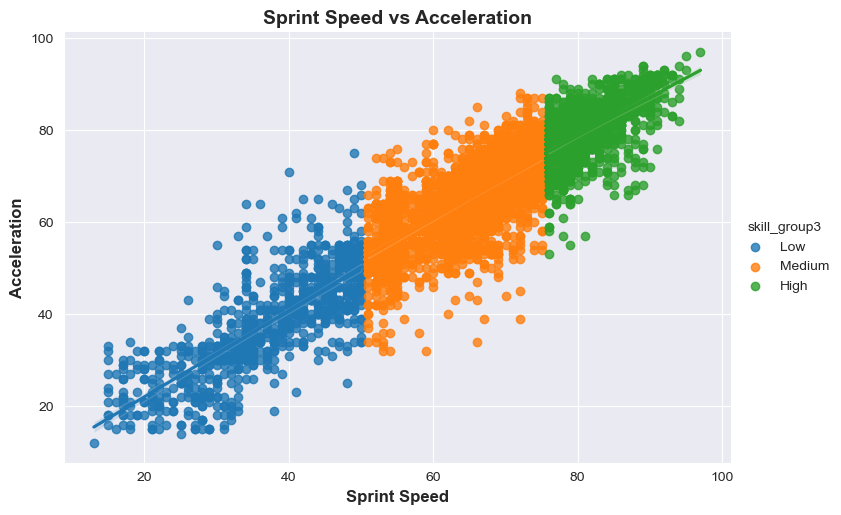

In [127]:
df['skill_group3'] = pd.cut(df['sprint_speed'], bins=[0, 50, 75, 100], labels=['Low', 'Medium', 'High'])

sns.set_style('darkgrid')
sns.lmplot(data=df,x='sprint_speed',y='acceleration',hue='skill_group3',height=5,aspect=1.5)
plt.title("Sprint Speed vs Acceleration", fontsize=14, fontweight='bold')
plt.xlabel("Sprint Speed", fontsize=12, fontweight='bold')
plt.ylabel("Acceleration", fontsize=12, fontweight='bold')

### heading -- jumping

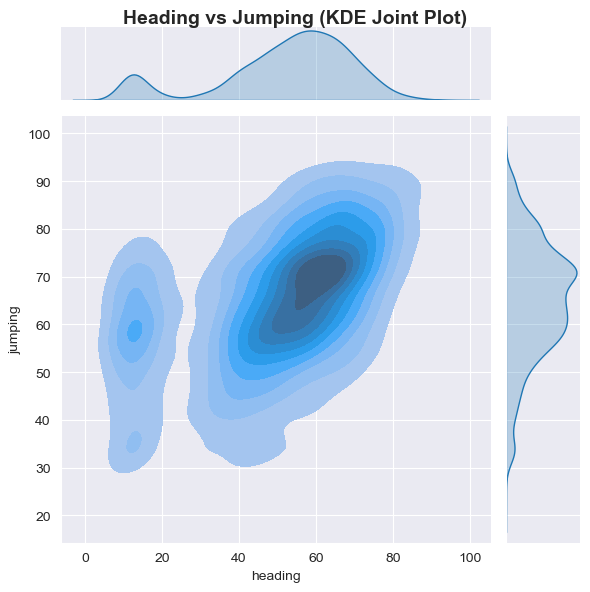

In [128]:
sns.set_style("darkgrid")
sns.jointplot(
    data=df,
    x="heading",
    y="jumping",
    kind="kde",
    fill=True,
    height=6
)
plt.suptitle("Heading vs Jumping (KDE Joint Plot)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.95)  
